# READ ME 

## 🧠 Company Success Prediction Project  
### 📊 Regression + Classification Analysis on Business & Culture Data  

---

## 📘 Overview
This project explores how **financial performance**, **innovation**, and **organizational culture** influence a company’s overall **Success Score**.  
Using a synthetic dataset of 18,000+ companies, we applied **machine learning** to uncover the key drivers of success — from **profit margins** to **employee well-being**.

---

## 🎯 Objectives
1. **Predict** a company’s overall success score (Regression).  
2. **Classify** companies as *High Success* or *Low Success* (Classification).  
3. **Identify** the most influential features shaping success.  
4. **Compare** balancing methods (Original, SMOTE, Random Oversampling).  

---


## ⚙️ Methods & Techniques

* **Data Preparation:**
  Cleaning, encoding, scaling (Min–Max), and class balancing using **SMOTE** and **Random Oversampling**.
* **Feature Selection:**
  Combination of **ANOVA F-test** and **Recursive Feature Elimination (RFE)** to retain the most relevant predictors.
* **Model Training:**
  * *Regression:* **Linear Regression**, **Random Forest**, **Gradient Boosting**
  * *Classification:* **Logistic Regression**, **SVM**, **Random Forest**, **Gradient Boosting**
  * Each model was validated using **5-fold Cross-Validation** for consistent performance estimation.

* **Hyperparameter Tuning:**

  * Optimized **Gradient Boosting Regressor** (Regression) using `GridSearchCV` to fine-tune learning rate, depth, and estimators.
  * Optimized **Random Forest (SMOTE)** (Classification) to identify best depth, split criteria, and estimator count.
  * Compared baseline vs. tuned versions to evaluate **performance stability vs. improvement**.

* **Evaluation Metrics:**

  * *Regression:* **R²**, **MAPE**
  * *Classification:* **Accuracy**, **Precision**, **Recall**, **F1-score**

---

## 📈 Key Insights
- 💰 **Profit Margin**, 🚀 **Innovation Index**, and 😊 **Customer Satisfaction** are the top predictors of success.  
- ⚖️ **Work-Life Balance** supports long-term stability and performance.  
- 📉 **Expense Ratio** and 🔁 **Employee Turnover Rate** negatively affect success.  
- 🧩 SMOTE balancing improved fairness in predicting *Low Success* firms.  

---

## 🏆 Final Takeaways
* **Linear Regression** delivered a strong, interpretable model for predicting the *Success Score* (R² ≈ 0.43, MAPE ≈ 10%).
* **Logistic Regression (Original)** achieved the **highest accuracy** for classifying *High vs. Low Success* (≈ 77%).
* **Random Forest with SMOTE** produced the **most balanced results**, improving recall and F1-score for the minority class.
* **Tuning confirmed** that both models were already well-calibrated — fine-tuning slightly improved precision but didn’t drastically change overall performance.

---

> 📂 **Author:** Amine Bouraoui-Emna Labben  
> 🎓 **Project:** Company Performance & Culture Analysis  
> 🧩 **Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  
> 📅 **Date:** October 2025  


# ⏳ 1) Import Libraries and Load the Data

In [1]:
# ------------------------------------------------------------------
# 1. Import  libraries
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# ------------------------------------------------------------------
# 2. Load the dataset
# ------------------------------------------------------------------
file_path = "company_performance_culture.xlsx"
df = pd.read_excel(file_path)

# Show first 5 rows
print(" Dataset loaded successfully. Here are the first 5 rows:")
df.head()


 Dataset loaded successfully. Here are the first 5 rows:


,Company_ID,Company_Name,Industry,Country,Ownership_Type,HQ_City,Employee_Count,Annual_Revenue_MUSD,Operating_Expenses_MUSD,Profit_Margin,Revenue_per_Employee_USD,Expense_Ratio,Avg_Salary_USD,Remote_Work_Allowed,Employee_Turnover_Rate,Innovation_Index,Customer_Satisfaction,Net_Promoter_Score,Work_Life_Balance,Diversity_Score,Leadership_Style,Training_Budget_Per_Employee,CSR_Engagement_Level,Environmental_Score,Success_Score,Success_Class
0,C00001,AgroTech,Energy,USA 🇺🇸,Private,Sfax,858.0,127.188,89.720,12.54,148237.67,0.705,1229,0.0,0.5,36.0,9.1,28.0,7.4,0.833,Authoritative,113,Low,69.0,65.45,High
1,C00002,HyperSystems,Finance,Germany 🇩🇪,Government,Paris,139.0,6.727,4.218,15.85,48392.92,0.627,1607,0.0,12.1,88.0,8.7,40.0,7.3,0.197,Laissez-Faire,293,High,97.0,75.95,High
2,C00003,NovaWorks,Logistics,NaN,Public,Munich,710.0,30.614,17.184,19.20,43118.97,0.561,NaN,0.0,11.6,81.0,8.6,59.0,6.2,NaN,Laissez-Faire,226,NaN,39.0,56.56,High
3,C00004,AgroGroup,Healthcare,Germany,NaN,Abu Dhabi,489.0,NaN,44.179,16.61,143867.77,0.628,3286,1.0,11.2,55.0,8.2,-31.0,8.5,0.324,Transformational,297,Low,28.0,56.17,High
4,C00005,AgroSolutions,NaN,Tunisia,Private,Tunis,266.0,62.885,53.288,6.89,NaN,0.847,3728,1.0,12.1,66.0,6.3,38.0,6.6,0.137,Transformational,268,NaN,59.0,42.15,Low


# 📐 2) Basic structure

In [2]:
# ------------------------------------------------------------------
# 3. Basic structure
# ------------------------------------------------------------------
print("Shape of the dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

# ------------------------------------------------------------------
# 4. Information about types and missing values
# ------------------------------------------------------------------
print("\n--- Dataset Info ---")
df.info()

# ------------------------------------------------------------------
# 5. Check for missing values
# ------------------------------------------------------------------
print("\n--- Missing Values per Column ---")
print(df.isnull().sum())

# ------------------------------------------------------------------
# 6. Quick statistical summary for numeric columns
# ------------------------------------------------------------------
print("\n--- Descriptive Statistics ---")
print(df.describe())

Shape of the dataset: (20000, 26)

Column names:
 ['Company_ID', 'Company_Name', 'Industry', 'Country', 'Ownership_Type', 'HQ_City', 'Employee_Count', 'Annual_Revenue_MUSD', 'Operating_Expenses_MUSD', 'Profit_Margin', 'Revenue_per_Employee_USD', 'Expense_Ratio', 'Avg_Salary_USD', 'Remote_Work_Allowed', 'Employee_Turnover_Rate', 'Innovation_Index', 'Customer_Satisfaction', 'Net_Promoter_Score', 'Work_Life_Balance', 'Diversity_Score', 'Leadership_Style', 'Training_Budget_Per_Employee', 'CSR_Engagement_Level', 'Environmental_Score', 'Success_Score', 'Success_Class']

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Company_ID                    20000 non-null  object 
 1   Company_Name                  20000 non-null  object 
 2   Industry                      17680 non-null  object 
 3  

# 🧠 3) Identify Numeric and Categorical Columns

Numeric columns ( 13 ):
['Employee_Count', 'Operating_Expenses_MUSD', 'Profit_Margin', 'Expense_Ratio', 'Remote_Work_Allowed', 'Employee_Turnover_Rate', 'Innovation_Index', 'Customer_Satisfaction', 'Net_Promoter_Score', 'Work_Life_Balance', 'Diversity_Score', 'Environmental_Score', 'Success_Score']

Categorical columns ( 13 ):
['Company_ID', 'Company_Name', 'Industry', 'Country', 'Ownership_Type', 'HQ_City', 'Annual_Revenue_MUSD', 'Revenue_per_Employee_USD', 'Avg_Salary_USD', 'Leadership_Style', 'Training_Budget_Per_Employee', 'CSR_Engagement_Level', 'Success_Class']


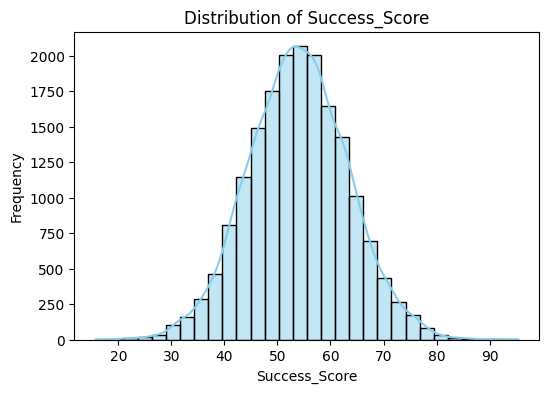

 Basic overview of target variable (Success_Score) displayed.


C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\2654867396.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Success_Class", data=df, palette='viridis')


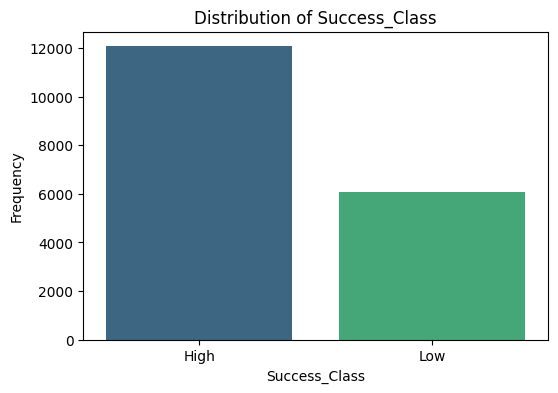

 Basic overview of target variable (Success_Class) displayed.


In [3]:
# ------------------------------------------------------------------
# 7. Separate numeric and categorical columns
# ------------------------------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns (", len(numeric_cols), "):")
print(numeric_cols)

print("\nCategorical columns (", len(categorical_cols), "):")
print(categorical_cols)

# ------------------------------------------------------------------
# 8. Show basic overview of target variable (Success_Score)
# ------------------------------------------------------------------
plt.figure(figsize=(6,4))
sns.histplot(df["Success_Score"], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Success_Score")
plt.xlabel("Success_Score")
plt.ylabel("Frequency")
plt.show()
print(" Basic overview of target variable (Success_Score) displayed.")

# ------------------------------------------------------------------
# 9. Show basic overview of target variable (Success_Class)
# ------------------------------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="Success_Class", data=df, palette='viridis')
plt.title("Distribution of Success_Class")
plt.xlabel("Success_Class")
plt.ylabel("Frequency")
plt.show()
print(" Basic overview of target variable (Success_Class) displayed.")


### 📊 Interpretation – Distribution of `Success_Score`

The distribution of `Success_Score` is approximately **bell-shaped and symmetric**, suggesting that most companies have a **moderate level of success**, centered around the **50–60 range**.  
- Only a small number of companies perform **extremely low or extremely high**, which indicates a balanced dataset without major bias.  
- This kind of distribution is useful for modeling, as it reflects a **normal-like pattern** often seen in real business performance indicators.


### 📊 Interpretation – Distribution of `Success_Class`

The dataset shows that **High Success** companies represent the majority, making up roughly **two-thirds of all observations**, while **Low Success** companies form about **one-third**.  
This indicates a **slight class imbalance**, but not severe enough to cause issues in model training.  
It also suggests that in this dataset, **most companies perform well overall**, which aligns with a realistic business environment where successful firms are more common than failing ones.


# 📊 4) Univariate Analysis

In [4]:
# --- Summary statistics for numeric variables ---
print("\n--- Descriptive Statistics (Numeric Columns) ---")
display(df.describe().T)



--- Descriptive Statistics (Numeric Columns) ---


,count,mean,std,min,25%,50%,75%,max
Employee_Count,18436.0,728.760794,597.791777,44.000,351.75000,564.0000,908.0000,8227.000
Operating_Expenses_MUSD,17494.0,75.453804,74.652303,2.768,30.03575,53.8685,95.1770,1383.615
Profit_Margin,17936.0,15.973011,5.430596,-48.340,13.35000,15.9700,18.6100,78.290
Expense_Ratio,17815.0,0.701260,0.115359,0.500,0.60200,0.7020,0.8010,0.900
Remote_Work_Allowed,18261.0,0.387219,0.487128,0.000,0.00000,0.0000,1.0000,1.000
Employee_Turnover_Rate,18191.0,10.359106,5.932590,0.000,6.00000,10.3000,14.4000,33.500
Innovation_Index,17750.0,60.878254,18.158395,0.000,49.00000,61.0000,73.0000,100.000
Customer_Satisfaction,18571.0,7.464811,1.109500,3.000,6.70000,7.5000,8.2000,10.000
Net_Promoter_Score,18120.0,26.556291,33.476555,-98.000,3.00000,27.0000,50.0000,100.000
Work_Life_Balance,18152.0,6.733148,1.227099,1.200,5.90000,6.7000,7.6000,10.000


### 📊 Interpretation – Descriptive Statistics (Numeric Columns)

The dataset shows a diverse range of company characteristics:

- **Employee_Count** averages around **729**, indicating most companies are medium-sized, though some very large firms exist (max over 8,000 employees).  
- **Financial indicators** like `Operating_Expenses_MUSD` and `Profit_Margin` show moderate variation, suggesting different cost structures and profitability levels across industries.  
- **Innovation_Index** and `Environmental_Score` both average near **60**, showing balanced performance in innovation and sustainability.  
- **Customer_Satisfaction** and `Work_Life_Balance` are relatively high (mean ≈ 7/10), indicating overall positive employee and customer sentiment.  
- **Success_Score** has an average of **54**, with a reasonable spread (std ≈ 9), confirming that most companies cluster near average performance with a few clear leaders and laggards.  

Overall, the data appears well-distributed, realistic, and suitable for both regression and classification analysis.


# ⚙️ 5) Bivariate Analysis

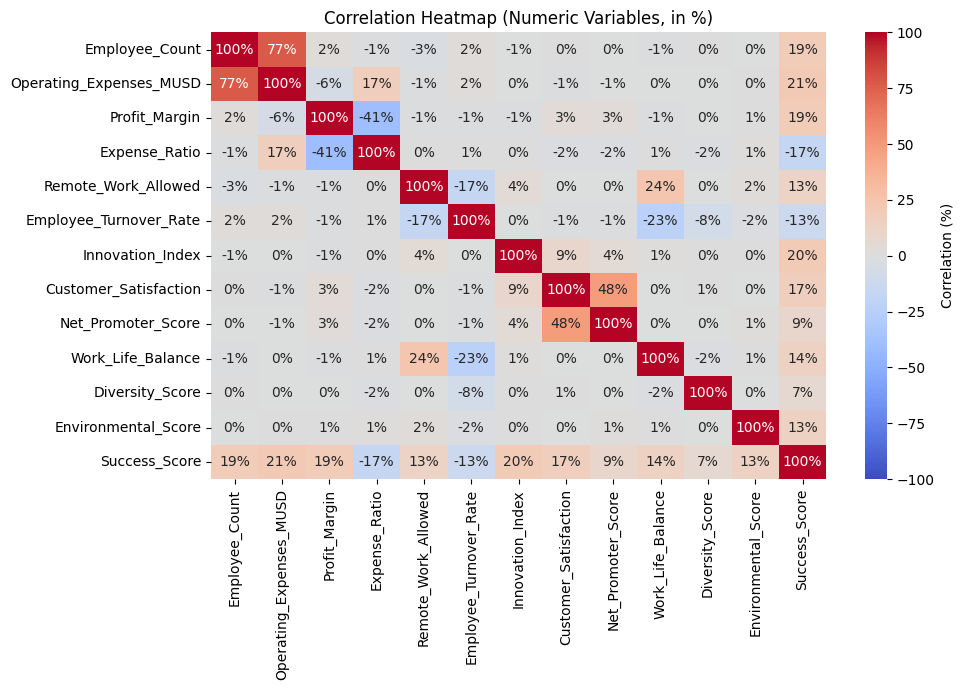

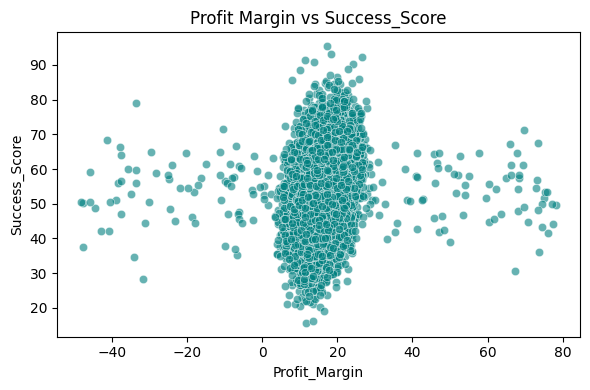

In [5]:
# ------------------------------------------------------------------
# Correlation heatmap (numeric variables) – show % inside
# ------------------------------------------------------------------
plt.figure(figsize=(10,7))
corr = df.select_dtypes(include=[np.number]).corr() * 100  # convert to percentage
annot_labels = corr.round(0).astype(int).astype(str) + "%"

sns.heatmap(corr, cmap='coolwarm', annot=annot_labels, fmt="", 
            cbar_kws={"label": "Correlation (%)"}, vmin=-100, vmax=100)

plt.title("Correlation Heatmap (Numeric Variables, in %)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Scatter plot: Profit_Margin vs Success_Score
# ------------------------------------------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Profit_Margin", y="Success_Score", alpha=0.6, color='teal')
plt.title("Profit Margin vs Success_Score")
plt.tight_layout()
plt.show()


### 🔗 Interpretation – Correlation Heatmap (Numeric Variables)

The correlation heatmap reveals several key insights:

- There is a **strong positive correlation (77%)** between `Employee_Count` and `Operating_Expenses_MUSD`, meaning larger companies naturally tend to spend more.  
- `Profit_Margin` shows a **moderate negative correlation (-41%)** with `Expense_Ratio`, which makes sense — companies with high expenses relative to revenue have lower margins.  
- `Success_Score` has **mild positive correlations** with `Employee_Count` (19%), `Operating_Expenses_MUSD` (21%), and `Innovation_Index` (20%), suggesting that **larger and more innovative firms tend to perform better overall**.  
- Other variables such as `Customer_Satisfaction`, `Work_Life_Balance`, and `Environmental_Score` have weaker relationships with success, but still contribute small positive effects.  

Overall, the correlations are logical and realistic — **no severe multicollinearity issues** are visible, and financial + innovation factors appear most linked to company success.


### 💰 Interpretation – Profit Margin vs Success_Score

The scatter plot shows a **positive but moderate relationship** between `Profit_Margin` and `Success_Score`.  
- Companies with **higher profit margins** generally tend to achieve **higher success scores**, indicating that financial efficiency contributes to overall success.  
- However, the spread of points suggests that profitability **is not the only driver** — some firms with average margins still perform well, likely due to other strengths such as innovation or customer satisfaction.  
- A few extreme values (very low or very high margins) highlight possible **outliers or exceptional business cases**.  

In summary, **profitability is important but not the sole determinant** of company success.


# 🧼 6) Data Cleaning & Preparation

In [6]:
# ------------------------------------------------------------------
#  Prepare dataset before cleaning
# ------------------------------------------------------------------

# 1 Set Company_ID as index
df.set_index("Company_ID", inplace=True)
print("✅ Company_ID set as index.")

# 2 Remove columns we don’t need
df.drop(columns=["Company_Name", "HQ_City"], inplace=True)
print("✅ Removed Company_Name and HQ_City columns.")

# Quick check
print("\nCurrent columns after cleanup:\n", df.columns.tolist())


✅ Company_ID set as index.
✅ Removed Company_Name and HQ_City columns.

Current columns after cleanup:
 ['Industry', 'Country', 'Ownership_Type', 'Employee_Count', 'Annual_Revenue_MUSD', 'Operating_Expenses_MUSD', 'Profit_Margin', 'Revenue_per_Employee_USD', 'Expense_Ratio', 'Avg_Salary_USD', 'Remote_Work_Allowed', 'Employee_Turnover_Rate', 'Innovation_Index', 'Customer_Satisfaction', 'Net_Promoter_Score', 'Work_Life_Balance', 'Diversity_Score', 'Leadership_Style', 'Training_Budget_Per_Employee', 'CSR_Engagement_Level', 'Environmental_Score', 'Success_Score', 'Success_Class']


In [7]:
# ------------------------------------------------------------------
#  Clean numeric columns and standardize object columns
# ------------------------------------------------------------------

#  Define which columns are numeric in THIS dataset (explicitly)
numeric_cols_expected = [
    "Employee_Count",
    "Annual_Revenue_MUSD",
    "Operating_Expenses_MUSD",
    "Profit_Margin",
    "Revenue_per_Employee_USD",
    "Expense_Ratio",
    "Avg_Salary_USD",
    "Remote_Work_Allowed",
    "Employee_Turnover_Rate",
    "Innovation_Index",
    "Customer_Satisfaction",
    "Net_Promoter_Score",
    "Work_Life_Balance",
    "Diversity_Score",
    "Training_Budget_Per_Employee",
    "Environmental_Score",
    "Success_Score"
]

#  Coerce numeric columns (remove commas etc. → float/int)
import re

for col in numeric_cols_expected:
    if col in df.columns:
        # Remove thousands separators and any non-numeric symbols (keep digits, dot, minus)
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace(r'[^0-9\.\-]', '', regex=True)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Cast obvious integer-like numeric columns to int (after coercion)
int_like_cols = [
    "Employee_Count",
    "Avg_Salary_USD",
    "Net_Promoter_Score",
    "Training_Budget_Per_Employee",
    "Remote_Work_Allowed"
]
for col in int_like_cols:
    if col in df.columns:
        # Fill temporary NaNs with median so astype doesn't fail; we'll re-impute properly below too
        df[col] = df[col].fillna(df[col].median())
        df[col] = df[col].astype(int)

#  Handle remaining missing values: numeric → median
for col in numeric_cols_expected:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

#  Standardize object columns:
# - remove extra spaces (trim + collapse multiple spaces to one)
# - UPPER → lower → Title Case (final: First Letter Upper)
obj_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

for col in obj_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'\s+', ' ', regex=True)  # collapse multiple spaces
        .str.strip()                           # remove leading/trailing spaces
        .str.upper()                           # (as requested) upper
        .str.lower()                           # then lower
        .str.title()                           # final: First Letter Upper
    )

print("✅ Step 16 done: numeric columns coerced, object columns cleaned.")

#  Print unique values for each object column (for your manual review)
for col in obj_cols:
    print(f"\n--- {col} ---")
    print("Unique count:", df[col].nunique(dropna=False))
    # Show the most common 30 values (keeps output readable)
    print(df[col].value_counts(dropna=False).head(30))


✅ Step 16 done: numeric columns coerced, object columns cleaned.

--- Industry ---
Unique count: 21
Industry
Nan              2320
Energy           1790
Agriculture      1764
Retail           1763
Education        1724
Healthcare       1689
Logistics        1684
Manufacturing    1682
Finance          1677
Technology       1675
Telecom          1672
Tech              115
Edu                57
Logi               56
Telco              55
Health             55
Fin                53
Agri               48
Manufacture        44
Fintech            41
Mfg                36
Name: count, dtype: int64

--- Country ---
Unique count: 21
Country
Nan           1857
Uk 🇬🇧         1767
Germany 🇩🇪    1735
Usa 🇺🇸        1733
Uae 🇦🇪        1728
Spain 🇪🇸      1710
Morocco 🇲🇦    1692
Turkey 🇹🇷     1666
Italy 🇮🇹      1651
France 🇫🇷     1646
Tunisia 🇹🇳    1604
Tunisia        143
Italy          129
Spain          127
Uk             126
Usa            125
Germany        122
Uae            111
Turkey         111


C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\1496819204.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\1496819204.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [8]:
# ------------------------------------------------------------------
# 🧹 Clean 'Industry' column (using mode to fill missing)
# ------------------------------------------------------------------

# Mapping of incorrect / abbreviated industry names to the correct one
industry_map = {
    "Tech": "Technology",
    "Telco": "Telecom",
    "Health": "Healthcare",
    "Edu": "Education",
    "Agri": "Agriculture",
    "Fin": "Finance",
    "Fintech": "Finance",
    "Mfg": "Manufacturing",
    "Manufacture": "Manufacturing",
    "Logi": "Logistics"
}

# Apply replacements
df["Industry"] = df["Industry"].replace(industry_map)

# Fill missing values with the mode (most frequent category)
df["Industry"].fillna(df["Industry"].mode()[0], inplace=True)

# Ensure consistent formatting (Title Case, no spaces)
df["Industry"] = df["Industry"].astype(str).str.strip().str.title()

# Verify result
print("\n✅ Cleaned 'Industry' column unique values:")
print(df["Industry"].value_counts(dropna=False))



✅ Cleaned 'Industry' column unique values:
Industry
Nan              2320
Agriculture      1812
Energy           1790
Technology       1790
Education        1781
Finance          1771
Retail           1763
Manufacturing    1762
Healthcare       1744
Logistics        1740
Telecom          1727
Name: count, dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\2638470819.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Industry"].fillna(df["Industry"].mode()[0], inplace=True)


In [9]:
# ------------------------------------------------------------------
# 🧹 Clean 'Country' column
# ------------------------------------------------------------------

# 1 Remove emojis/flags using regex (anything outside letters or spaces)
df["Country"] = (
    df["Country"]
    .astype(str)
    .str.replace(r"[^A-Za-z\s]", "", regex=True)  # remove emojis and symbols
    .str.strip()
    .str.title()
)

# 2 Replace abbreviations / short forms
country_map = {
    "Usa": "United States",
    "Uk": "United Kingdom",
    "Uae": "United Arab Emirates",
    "France": "France",
    "Germany": "Germany",
    "Italy": "Italy",
    "Spain": "Spain",
    "Morocco": "Morocco",
    "Tunisia": "Tunisia",
    "Turkey": "Turkey"
}

df["Country"] = df["Country"].replace(country_map)

# 3 Fill missing values with the mode (most common country)
df["Country"].fillna(df["Country"].mode()[0], inplace=True)

# 4 Ensure clean Title Case
df["Country"] = df["Country"].astype(str).str.strip().str.title()

# ✅ Verify results
print("\n✅ Cleaned 'Country' column unique values:")
print(df["Country"].value_counts(dropna=False))


C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\3920438632.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Country"].fillna(df["Country"].mode()[0], inplace=True)



✅ Cleaned 'Country' column unique values:
Country
United Kingdom          1893
United States           1858
Germany                 1857
Nan                     1857
United Arab Emirates    1839
Spain                   1837
Morocco                 1800
Italy                   1780
Turkey                  1777
France                  1755
Tunisia                 1747
Name: count, dtype: int64


In [10]:
# ------------------------------------------------------------------
# 🧹 Fix: Clean up 'Nan' strings and refill missing
# ------------------------------------------------------------------

# Replace "Nan", "nan", "NaN", etc. strings with actual NaN values
df["Country"] = df["Country"].replace(["Nan", "nan", "NaN", "None", "Null", ""], np.nan)

# Now fill missing with mode again
df["Country"].fillna(df["Country"].mode()[0], inplace=True)

# Final title-case standardization
df["Country"] = df["Country"].astype(str).str.strip().str.title()

# ✅ Check result again
print("\n✅ Final Cleaned 'Country' column unique values:")
print(df["Country"].value_counts(dropna=False))



✅ Final Cleaned 'Country' column unique values:
Country
United Kingdom          3750
United States           1858
Germany                 1857
United Arab Emirates    1839
Spain                   1837
Morocco                 1800
Italy                   1780
Turkey                  1777
France                  1755
Tunisia                 1747
Name: count, dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\2145065277.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Country"].fillna(df["Country"].mode()[0], inplace=True)


In [11]:
# ------------------------------------------------------------------
# 🧹 Clean 'Ownership_Type' column
# ------------------------------------------------------------------

# 1 Replace text "Nan"/"nan"/"NaN" etc. with real NaN
df["Ownership_Type"] = df["Ownership_Type"].replace(["Nan", "nan", "NaN", "None", "Null", ""], np.nan)

# 2 Mapping of variations and abbreviations to correct names
ownership_map = {
    "Gov": "Government",
    "Non Profit": "Non-Profit",
    "Nonprofit": "Non-Profit"
}

df["Ownership_Type"] = df["Ownership_Type"].replace(ownership_map)

# 3 Fill missing values with mode (most common ownership type)
df["Ownership_Type"].fillna(df["Ownership_Type"].mode()[0], inplace=True)

# 4 Clean spaces and ensure Title Case
df["Ownership_Type"] = df["Ownership_Type"].astype(str).str.strip().str.title()

# ✅ Verify results
print("\n✅ Cleaned 'Ownership_Type' column unique values:")
print(df["Ownership_Type"].value_counts(dropna=False))



✅ Cleaned 'Ownership_Type' column unique values:
Ownership_Type
Private       10948
Public         5476
Non-Profit     1791
Government     1785
Name: count, dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\3665181443.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Ownership_Type"].fillna(df["Ownership_Type"].mode()[0], inplace=True)


In [12]:
# ------------------------------------------------------------------
# 🧹 Clean 'Leadership_Style' column
# ------------------------------------------------------------------

# 1 Replace text "Nan"/"nan"/"NaN"/"None" etc. with actual NaN
df["Leadership_Style"] = df["Leadership_Style"].replace(["Nan", "nan", "NaN", "None", "Null", ""], np.nan)

# 2 Map short versions to full names
leadership_map = {
    "Demo": "Democratic",
    "Trans": "Transformational",
    "Auth": "Authoritative",
    "Lf": "Laissez-Faire"
}

df["Leadership_Style"] = df["Leadership_Style"].replace(leadership_map)

# 3 Fill missing values with the mode (most common style)
df["Leadership_Style"].fillna(df["Leadership_Style"].mode()[0], inplace=True)

# 4 Clean extra spaces and ensure proper formatting (Title Case)
df["Leadership_Style"] = df["Leadership_Style"].astype(str).str.strip().str.title()

# ✅ Verify the results
print("\n✅ Cleaned 'Leadership_Style' column unique values:")
print(df["Leadership_Style"].value_counts(dropna=False))



✅ Cleaned 'Leadership_Style' column unique values:
Leadership_Style
Democratic          8184
Transformational    4618
Authoritative       4479
Laissez-Faire       2719
Name: count, dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\2255486740.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Leadership_Style"].fillna(df["Leadership_Style"].mode()[0], inplace=True)


In [13]:
# ------------------------------------------------------------------
# 🧹 Clean 'CSR_Engagement_Level' column
# ------------------------------------------------------------------

# 1 Replace text "Nan"/"nan"/"NaN"/"None" etc. with real NaN
df["CSR_Engagement_Level"] = df["CSR_Engagement_Level"].replace(
    ["Nan", "nan", "NaN", "None", "Null", ""], np.nan
)

# 2 Fix short form
csr_map = {"Med": "Medium"}
df["CSR_Engagement_Level"] = df["CSR_Engagement_Level"].replace(csr_map)

# 3 Fill missing values with mode (most frequent level)
df["CSR_Engagement_Level"].fillna(df["CSR_Engagement_Level"].mode()[0], inplace=True)

# 4 Standardize format (remove spaces + Title Case)
df["CSR_Engagement_Level"] = df["CSR_Engagement_Level"].astype(str).str.strip().str.title()

# ✅ Verify the results
print("\n✅ Cleaned 'CSR_Engagement_Level' column unique values:")
print(df["CSR_Engagement_Level"].value_counts(dropna=False))



✅ Cleaned 'CSR_Engagement_Level' column unique values:
CSR_Engagement_Level
Medium    10719
High       4653
Low        4628
Name: count, dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\2515306205.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CSR_Engagement_Level"].fillna(df["CSR_Engagement_Level"].mode()[0], inplace=True)


In [14]:
# ------------------------------------------------------------------
# 🧹 Clean 'Success_Class' column
# ------------------------------------------------------------------

# 1 Replace text "Nan"/"nan"/"NaN"/"None" etc. with real NaN
df["Success_Class"] = df["Success_Class"].replace(["Nan", "nan", "NaN", "None", "Null", ""], np.nan)

# 2 Fill missing values with the mode (most frequent value)
df["Success_Class"].fillna(df["Success_Class"].mode()[0], inplace=True)

# 3 Standardize format: remove spaces + Title Case
df["Success_Class"] = df["Success_Class"].astype(str).str.strip().str.title()

# ✅ Verify results
print("\n✅ Cleaned 'Success_Class' column unique values:")
print(df["Success_Class"].value_counts(dropna=False))



✅ Cleaned 'Success_Class' column unique values:
Success_Class
High    13917
Low      6083
Name: count, dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\3835999540.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Success_Class"].fillna(df["Success_Class"].mode()[0], inplace=True)


In [15]:
# ------------------------------------------------------------------
# 🧹  Remove duplicate rows
# ------------------------------------------------------------------

before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"✅ Removed {before - after} duplicate rows. Final shape: {df.shape}")

✅ Removed 0 duplicate rows. Final shape: (20000, 23)


In [16]:
# ------------------------------------------------------------------
#  One-Hot Encode Categorical Variables (excluding target)
# ------------------------------------------------------------------

# 1 Identify categorical columns to encode (exclude Success_Class)
categorical_cols = [
    col for col in df.select_dtypes(exclude=[np.number]).columns
    if col != "Success_Class"
]

print("Categorical columns to encode:", categorical_cols)

# 2 Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# 3 Verify
print("\n✅ One-Hot Encoding applied successfully.")
print("Original shape:", df.shape)
print("New shape after encoding:", df_encoded.shape)



# 5 Confirm target columns still exist
print("\nCheck targets still present:")
print([col for col in df_encoded.columns if col in ["Success_Score", "Success_Class"]])


Categorical columns to encode: ['Industry', 'Country', 'Ownership_Type', 'Leadership_Style', 'CSR_Engagement_Level']

✅ One-Hot Encoding applied successfully.
Original shape: (20000, 23)
New shape after encoding: (20000, 50)

Check targets still present:
['Success_Score', 'Success_Class']


In [17]:
# ------------------------------------------------------------------
#  Outlier Detection and Treatment (IQR Method)
# ------------------------------------------------------------------

# Select numeric columns only (excluding IDs and encoded dummies)
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target columns
numeric_cols = [col for col in numeric_cols if col not in ["Success_Score", "Success_Class"]]

print("Numeric columns to check for outliers:", len(numeric_cols))

outlier_counts = {}

# Loop through numeric columns
for col in numeric_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count outliers before capping
    outliers = ((df_encoded[col] < lower) | (df_encoded[col] > upper)).sum()
    outlier_counts[col] = int(outliers)

    # Cap outliers (winsorization)
    df_encoded[col] = np.where(df_encoded[col] < lower, lower,
                        np.where(df_encoded[col] > upper, upper, df_encoded[col]))

print("\n✅ Outlier capping completed.")
print("Number of outliers capped per column (top 15):")
outlier_summary = pd.Series(outlier_counts).sort_values(ascending=False)
print(outlier_summary.head(15))


Numeric columns to check for outliers: 16

✅ Outlier capping completed.
Number of outliers capped per column (top 15):
Annual_Revenue_MUSD             1502
Operating_Expenses_MUSD         1445
Employee_Count                  1283
Training_Budget_Per_Employee     935
Profit_Margin                    409
Avg_Salary_USD                   273
Work_Life_Balance                269
Innovation_Index                 199
Customer_Satisfaction            156
Employee_Turnover_Rate           149
Environmental_Score              140
Net_Promoter_Score               130
Revenue_per_Employee_USD          84
Expense_Ratio                      0
Remote_Work_Allowed                0
dtype: int64


## 🧼 6) Data Cleaning & Preparation

This step prepared the dataset for analysis and modeling by fixing structure, missing values, and formatting issues.  

### 🔧 Main Actions Performed

1. **Initial Setup**
   - Set `Company_ID` as the index to uniquely identify each record.  
   - Removed unnecessary columns (`Company_Name`, `HQ_City`) that add no analytical value.  

2. **Numeric Columns**
   - Converted all numeric fields to the correct data type (float or int).  
   - Removed commas, symbols, and invalid characters.  
   - Filled missing numeric values with the **median** to avoid bias.  

3. **Categorical (Object) Columns**
   - Standardized text formatting:
     - Removed extra spaces  
     - Converted to *Title Case* (first letter upper, rest lower)  
   - Cleaned abbreviations and short forms (e.g., `Tech` → `Technology`, `Gov` → `Government`).  
   - Replaced “Nan”, “Null”, etc., with actual missing values and filled them using the **mode**.  

4. **Specific Column Fixes**
   - **Industry:** corrected short codes and filled missing values.  
   - **Country:** removed emojis/flags, standardized names, and fixed missing entries.  
   - **Ownership_Type, Leadership_Style, CSR_Engagement_Level, Success_Class:** unified naming and imputed missing values with the most frequent category.  

5. **Duplicates & Outliers**
   - Removed duplicate records to keep unique companies only.  
   - Detected and capped extreme outliers using the **IQR method**, ensuring values stay within realistic limits.  

6. **Encoding Categorical Variables**
   - Applied **One-Hot Encoding** to convert text categories into numeric format (while keeping `Success_Class` as the target).  

---

**Result:**  
The dataset is now clean, consistent, and machine-learning-ready — all numeric features are standardized, categorical fields encoded, and outliers handled for more stable model training.


# 📈 7) Advanced Data Visualization (Deep EDA)

## 🧪    7_1 ) Financial Metrics Visualization


Now that our data is cleaned and ready, let’s explore the **financial structure** of the companies.
These visualizations will help us understand how **revenue**, **expenses**, and **profit margins**
relate to overall company success.

We'll focus on three key questions:

1. What is the **distribution** of company profitability?  
2. Does **Profit Margin** clearly differ between *High* and *Low* success companies?  
3. How do **Revenue** and **Profit Margin** interact across success levels?


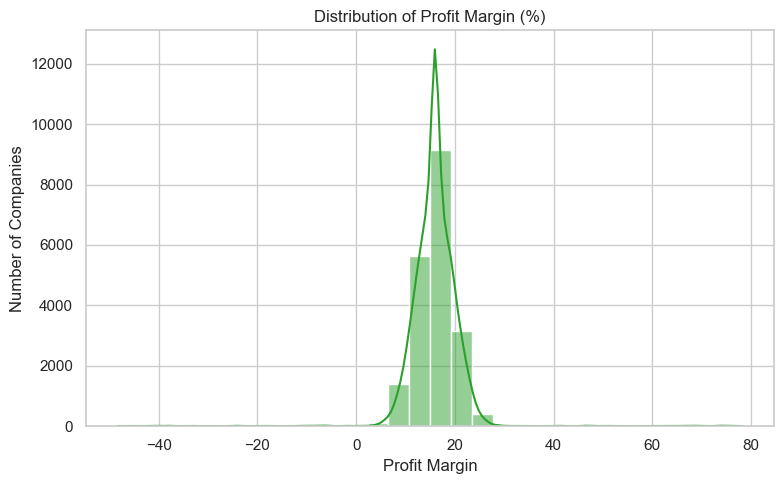

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\2640766488.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Success_Class", y="Profit_Margin", data=df, palette=["#ef233c", "#2ca02c"])


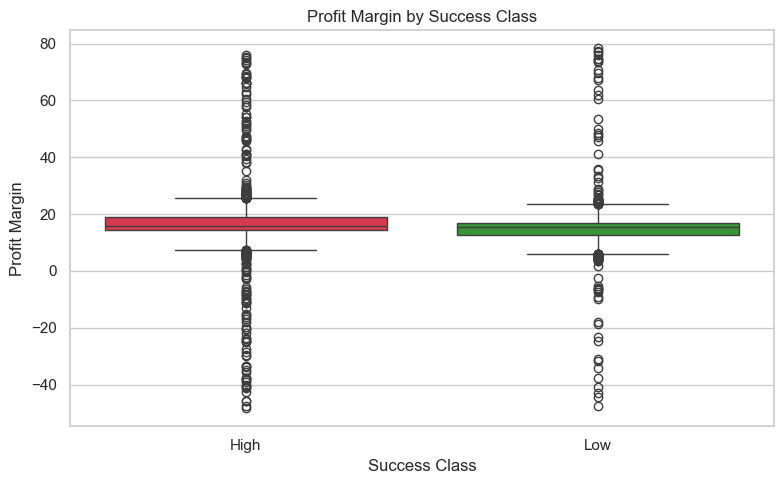

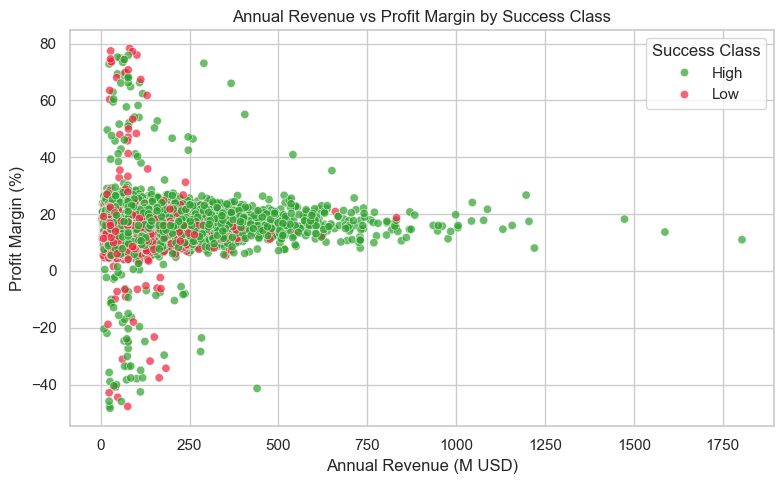

In [18]:
# ------------------------------------------------------------------
# 📦 Libraries
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ------------------------------------------------------------------
# 1️⃣ Histogram of Profit Margin
# ------------------------------------------------------------------
plt.figure()
sns.histplot(df["Profit_Margin"], kde=True, color="#2ca02c", bins=30)
plt.title("Distribution of Profit Margin (%)")
plt.xlabel("Profit Margin")
plt.ylabel("Number of Companies")
plt.tight_layout()
plt.show()

# 💬 Interpretation:
# This shows how profitability is distributed across companies.
# A right-skewed shape = many low-margin companies; a centered shape = balanced profitability.

# ------------------------------------------------------------------
# 2️⃣ Boxplot of Profit Margin by Success Class
# ------------------------------------------------------------------
plt.figure()
sns.boxplot(x="Success_Class", y="Profit_Margin", data=df, palette=["#ef233c", "#2ca02c"])
plt.title("Profit Margin by Success Class")
plt.xlabel("Success Class")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.show()

# 💬 Interpretation:
# Compare medians: higher median profit margins for “High Success” suggest profitability drives success.

# ------------------------------------------------------------------
# 3️⃣ Scatterplot: Annual Revenue vs Profit Margin (colored by Success Class)
# ------------------------------------------------------------------
plt.figure()
sns.scatterplot(
    x="Annual_Revenue_MUSD",
    y="Profit_Margin",
    hue="Success_Class",
    data=df,
    palette={"Low": "#ef233c", "High": "#2ca02c"},
    alpha=0.7
)
plt.title("Annual Revenue vs Profit Margin by Success Class")
plt.xlabel("Annual Revenue (M USD)")
plt.ylabel("Profit Margin (%)")
plt.legend(title="Success Class")
plt.tight_layout()
plt.show()

# 💬 Interpretation:
# This plot reveals whether larger companies (higher revenue) tend to be more profitable
# and how that profitability aligns with their success classification.


### 📊 7_1) Financial Metrics Visualization

Now that our dataset is clean, we explore how companies perform financially through **Profit Margin**, **Revenue**, and **Success Class**.

#### 🔹 1. Distribution of Profit Margin (%)
The first graph shows that most companies have a **Profit Margin between 10% and 20%**, forming a sharp peak around the average.  
Only a few firms have very high or negative margins, meaning extreme profits or losses are rare.

#### 🔹 2. Profit Margin by Success Class
The second boxplot shows that **High Success** companies generally maintain **slightly higher profit margins** and more consistency,  
while **Low Success** ones display more variability and outliers — indicating unstable profitability.

#### 🔹 3. Annual Revenue vs Profit Margin
The third scatter plot reveals that **revenue and profit margin are weakly related**.  
Both high- and low-success companies appear across revenue levels, suggesting that **profitability matters more than size**  
when defining company success.

---

✅ **Insight:**  
Stable and positive profit margins are more common among high-performing companies,  
but large revenue alone doesn’t guarantee success.


## 🧪 7_2 ) Employee & Culture Visualization

In this section, we analyze **how people-related factors** influence company success.
These variables represent the company’s *internal culture and human-resources health*.

We focus on two major aspects:
1. **Work-Life Balance** – employee well-being and satisfaction  
2. **Employee Turnover Rate** – organizational stability and retention

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\1516151328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Success_Class", y="Work_Life_Balance", data=df,


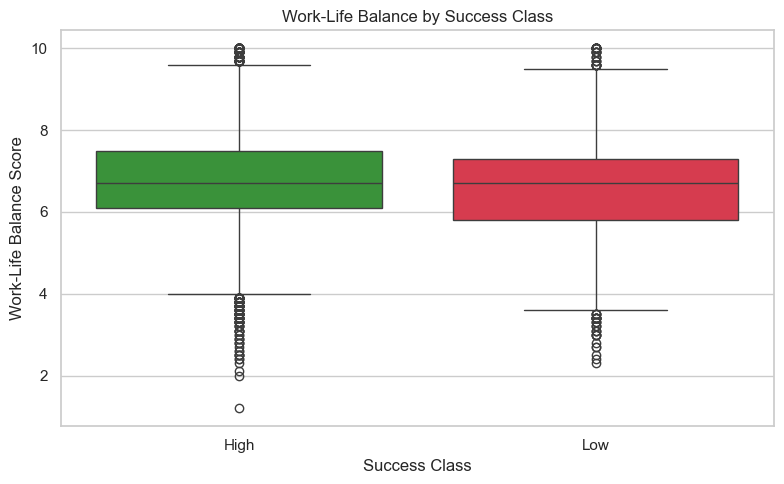

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\1516151328.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Success_Class", y="Employee_Turnover_Rate", data=df,


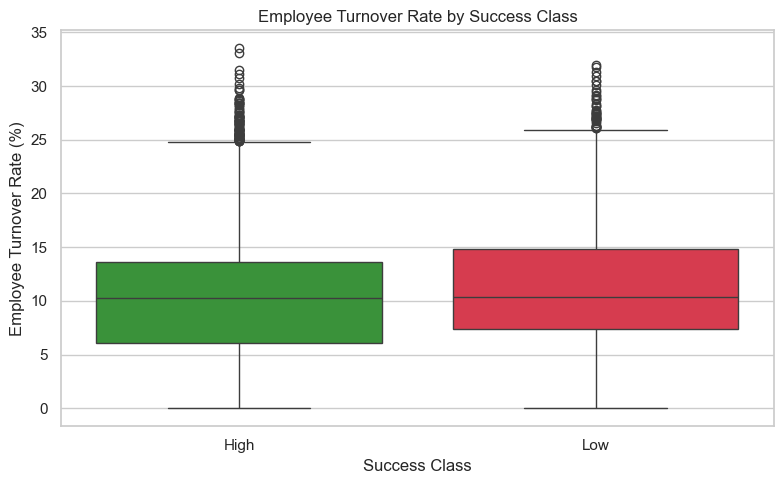

In [19]:
# ------------------------------------------------------------------
# 1️⃣ Boxplot: Work-Life Balance by Success Class
# ------------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="Success_Class", y="Work_Life_Balance", data=df,
            palette={"Low": "#ef233c", "High": "#2ca02c"})
plt.title("Work-Life Balance by Success Class")
plt.xlabel("Success Class")
plt.ylabel("Work-Life Balance Score")
plt.tight_layout()
plt.show()

# 💬 Interpretation:
# We can compare how employee work-life satisfaction differs between High vs Low Success companies.


# ------------------------------------------------------------------
# 2️⃣ Boxplot: Employee Turnover Rate by Success Class
# ------------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="Success_Class", y="Employee_Turnover_Rate", data=df,
            palette={"Low": "#ef233c", "High": "#2ca02c"})
plt.title("Employee Turnover Rate by Success Class")
plt.xlabel("Success Class")
plt.ylabel("Employee Turnover Rate (%)")
plt.tight_layout()
plt.show()

# 💬 Interpretation:
# Lower turnover often indicates better HR management, stability, and employee satisfaction.



### 👥 7_2) Employee & Culture Visualization

This section explores how internal culture and HR factors differ between **High** and **Low Success** companies.

#### 🔹 1. Work-Life Balance by Success Class
The boxplot shows that **High Success companies** tend to offer a slightly **better work-life balance**.  
While the difference isn’t huge, their median score is higher, and they show fewer extreme low values —  
suggesting that maintaining employee well-being supports consistent company performance.

#### 🔹 2. Employee Turnover Rate by Success Class
Here we see that **Low Success companies** experience **higher employee turnover rates**.  
High Success firms generally keep turnover under better control, indicating stronger retention and internal stability.

---

✅ **Insight:**  
Companies with healthier workplace culture — better work-life balance and lower turnover —  
are more likely to achieve long-term success.

## 🧪 7_3 ) Innovation & Sustainability Visualization

Innovation and sustainability often determine whether a company can stay competitive in the long run.  
Here, we explore three important drivers of modern success:

1. **Innovation Index** – how forward-thinking and adaptable the company is.  
2. **Customer Satisfaction** – how well products or services meet expectations.  
3. **Environmental Score** – how responsible and eco-conscious the organization is.

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\3166424891.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


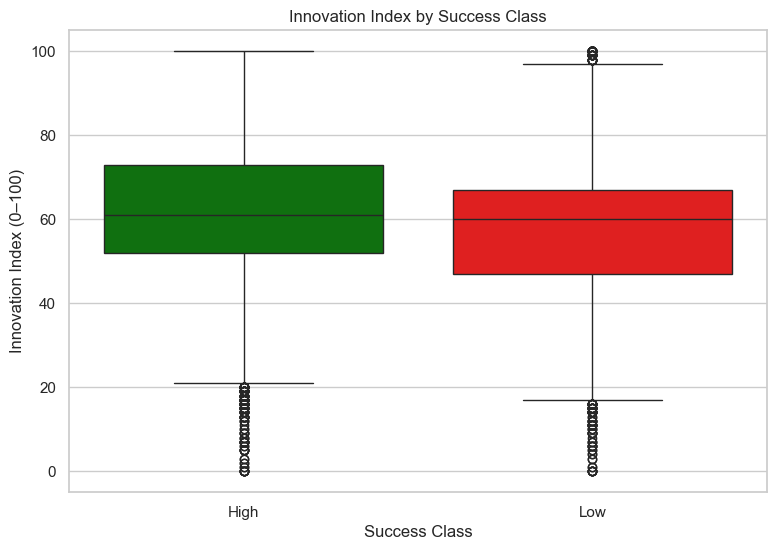

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\3166424891.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Success_Class", y="Customer_Satisfaction", data=df,


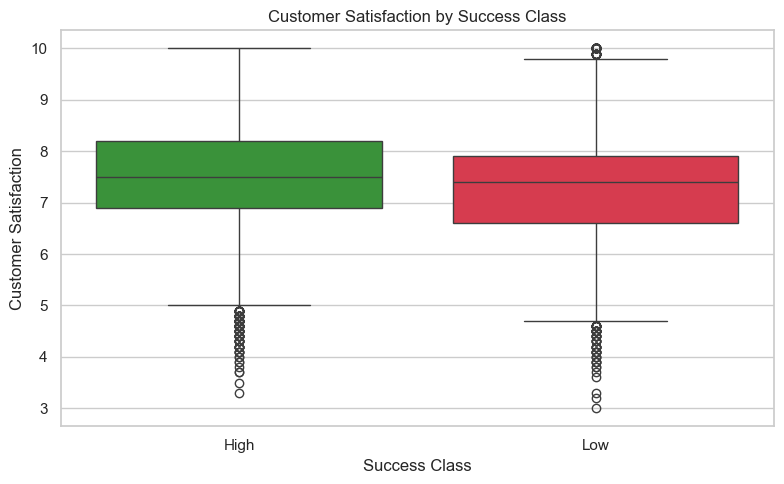

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\3166424891.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Success_Class", y="Environmental_Score", data=df,


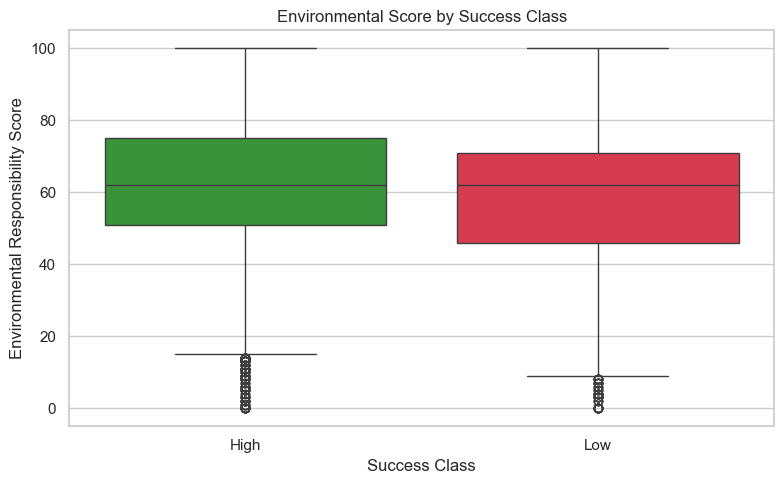

In [20]:
# ------------------------------------------------------------
# Innovation Index vs Success Class
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))
sns.boxplot(
    x="Success_Class",
    y="Innovation_Index",
    data=df,
    palette=["green", "red"]
)
plt.title("Innovation Index by Success Class")
plt.xlabel("Success Class")
plt.ylabel("Innovation Index (0–100)")
plt.show()

# ------------------------------------------------------------------
# 2 Boxplot: Customer Satisfaction by Success Class
# ------------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="Success_Class", y="Customer_Satisfaction", data=df,
            palette={"Low": "#ef233c", "High": "#2ca02c"})
plt.title("Customer Satisfaction by Success Class")
plt.xlabel("Success Class")
plt.ylabel("Customer Satisfaction")
plt.tight_layout()
plt.show()

# 💬 Interpretation:
# Compare satisfaction levels — higher averages among High Success firms confirm customer loyalty’s impact on success.


# ------------------------------------------------------------------
# 3 Boxplot: Environmental Score by Success Class
# ------------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="Success_Class", y="Environmental_Score", data=df,
            palette={"Low": "#ef233c", "High": "#2ca02c"})
plt.title("Environmental Score by Success Class")
plt.xlabel("Success Class")
plt.ylabel("Environmental Responsibility Score")
plt.tight_layout()
plt.show()


### 🌿 7_3) Innovation & Sustainability Visualization

#### 🔹 Innovation Index
High-success companies tend to have **higher innovation scores**, showing that being more creative and adaptable helps drive better results.

#### 🔹 Customer Satisfaction
High-success companies have **slightly higher satisfaction levels**, meaning their customers are generally happier and more loyal.

#### 🔹 Environmental Score
High-success firms also show **stronger environmental responsibility**, suggesting that sustainability goes hand in hand with strong business performance.


## 🧪 7_4 ) Ownership & Geography Visualization

In this final visualization step, we analyze how **location** and **ownership structure**
influence company success.

These factors often reflect differences in **economic environment**, **market maturity**, and **management style**.

We’ll look at:
1. **Average Success Score by Country**  
2. **Average Success Score by Industry**  
3. **Average Success Score by Ownership Type**

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\1431465232.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Success_Score", data=df, order=country_order, palette="viridis")


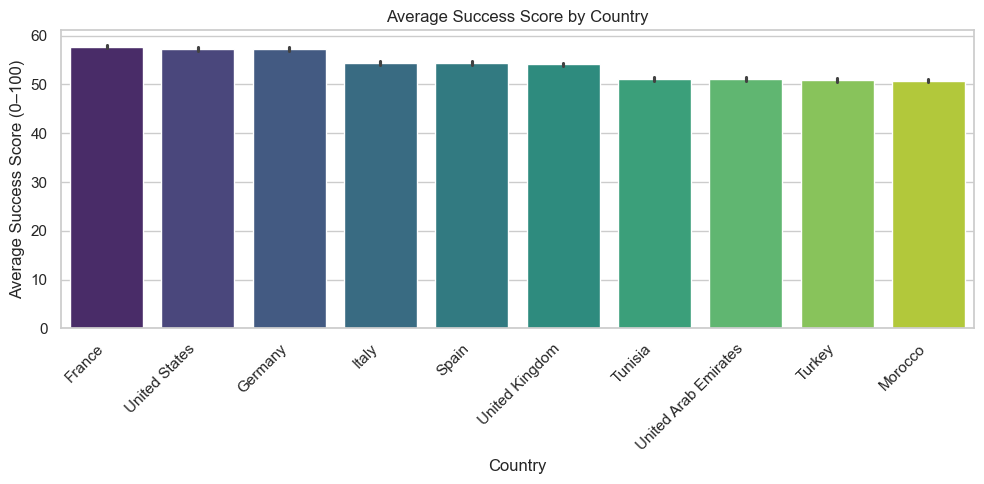

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\1431465232.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Industry", y="Success_Score", data=df, order=industry_order, palette="crest")


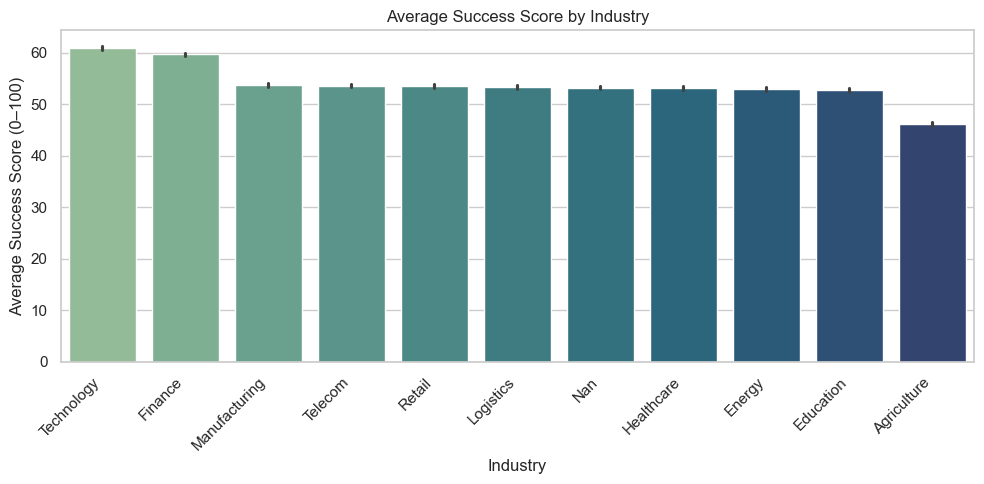

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\1431465232.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Ownership_Type", y="Success_Score", data=df, order=ownership_order, palette="magma")


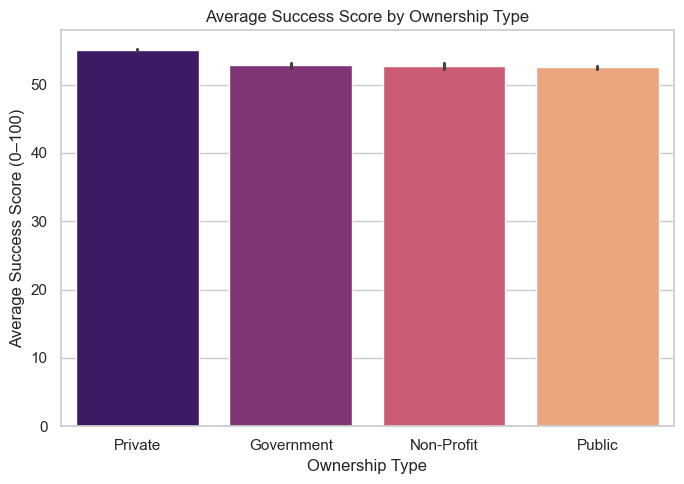

In [21]:
# ------------------------------------------------------------------
# 1️⃣ Barplot: Average Success Score by Country
# ------------------------------------------------------------------
plt.figure(figsize=(10,5))
country_order = df.groupby("Country")["Success_Score"].mean().sort_values(ascending=False).index
sns.barplot(x="Country", y="Success_Score", data=df, order=country_order, palette="viridis")
plt.title("Average Success Score by Country")
plt.xlabel("Country")
plt.ylabel("Average Success Score (0–100)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 💬 Interpretation:
# This highlights which countries host the most successful companies on average.


# ------------------------------------------------------------------
# 2️⃣ Barplot: Average Success Score by Industry
# ------------------------------------------------------------------
plt.figure(figsize=(10,5))
industry_order = df.groupby("Industry")["Success_Score"].mean().sort_values(ascending=False).index
sns.barplot(x="Industry", y="Success_Score", data=df, order=industry_order, palette="crest")
plt.title("Average Success Score by Industry")
plt.xlabel("Industry")
plt.ylabel("Average Success Score (0–100)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 💬 Interpretation:
# Allows us to identify the top-performing industries across all regions.


# ------------------------------------------------------------------
# 3️⃣ Barplot: Average Success Score by Ownership Type
# ------------------------------------------------------------------
plt.figure(figsize=(7,5))
ownership_order = df.groupby("Ownership_Type")["Success_Score"].mean().sort_values(ascending=False).index
sns.barplot(x="Ownership_Type", y="Success_Score", data=df, order=ownership_order, palette="magma")
plt.title("Average Success Score by Ownership Type")
plt.xlabel("Ownership Type")
plt.ylabel("Average Success Score (0–100)")
plt.tight_layout()
plt.show()

# 💬 Interpretation:
# Reveals how different organizational structures perform on average.


### 🌍 7_4) Ownership & Geography Visualization

#### 🔹 Success by Country  
France and the United States lead with the **highest average success scores**, followed by Germany and Italy.  
This suggests that companies from more mature markets tend to perform better overall.

#### 🔹 Success by Industry  
The **Technology** and **Finance** sectors clearly outperform others, reflecting the advantage of innovation-driven and financially stable industries.  
Traditional sectors like Agriculture and Education show lower success averages.

#### 🔹 Success by Ownership Type  
**Private companies** show slightly higher success compared to government or public ones,  
possibly due to more flexibility and faster decision-making.

---

✅ **Insight:**  
Company success is shaped not only by internal factors but also by **where** the company operates and **how** it is structured.  
Innovation-driven industries and flexible ownership models tend to perform best globally.

# 📗 8) Success_Score (Regression)

## 🟢 8-1) Feature Scaling & Model Data Preparation

In [22]:
# ------------------------------------------------------------------
#  Feature Scaling & Model Data Preparation
# ------------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1 Define target and features
target = "Success_Score"
X = df_encoded.drop(columns=[target, "Success_Class"])   # remove both targets from predictors
y = df_encoded[target]

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

# 2 Scale numeric features (MinMaxScaler)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("\n Features scaled successfully (0–1 range).")
print("Example scaled features:")
display(X_scaled.head())

# 3 Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\n Train/test split done.")
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)


Shape of X (features): (20000, 48)
Shape of y (target): (20000,)

 Features scaled successfully (0–1 range).
Example scaled features:


,Employee_Count,Annual_Revenue_MUSD,Operating_Expenses_MUSD,Profit_Margin,Revenue_per_Employee_USD,Expense_Ratio,Avg_Salary_USD,Remote_Work_Allowed,Employee_Turnover_Rate,Innovation_Index,Customer_Satisfaction,Net_Promoter_Score,Work_Life_Balance,Diversity_Score,Training_Budget_Per_Employee,Environmental_Score,Industry_Agriculture,Industry_Education,Industry_Energy,Industry_Finance,Industry_Healthcare,Industry_Logistics,Industry_Manufacturing,Industry_Nan,Industry_Retail,Industry_Technology,Industry_Telecom,Country_France,Country_Germany,Country_Italy,Country_Morocco,Country_Spain,Country_Tunisia,Country_Turkey,Country_United Arab Emirates,Country_United Kingdom,Country_United States,Ownership_Type_Government,Ownership_Type_Non-Profit,Ownership_Type_Private,Ownership_Type_Public,Leadership_Style_Authoritative,Leadership_Style_Democratic,Leadership_Style_Laissez-Faire,Leadership_Style_Transformational,CSR_Engagement_Level_High,CSR_Engagement_Level_Low,CSR_Engagement_Level_Medium
Company_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
C00001,0.519920,0.529346,0.526991,0.312500,0.373954,0.5125,0.171792,0.0,0.020,0.214724,0.830189,0.536977,0.608333,0.834677,0.119346,0.649718,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
C00002,0.060679,0.016250,0.008788,0.493969,0.078518,0.3175,0.260870,0.0,0.484,0.852761,0.754717,0.614148,0.591667,0.193548,0.460336,0.966102,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
C00003,0.425389,0.117995,0.087371,0.677632,0.062913,0.1525,0.475315,0.0,0.464,0.766871,0.735849,0.736334,0.408333,0.527218,0.333412,0.310734,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
C00004,0.284232,0.317058,0.250980,0.535636,0.361024,0.3200,0.656534,1.0,0.448,0.447853,0.660377,0.157556,0.791667,0.321573,0.467914,0.186441,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
C00005,0.141796,0.255451,0.306187,0.002741,0.396635,0.8675,0.760693,1.0,0.484,0.582822,0.301887,0.601286,0.475000,0.133065,0.412977,0.536723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0



 Train/test split done.
Training set: (16000, 48)
Testing set : (4000, 48)


### ⚙️ 8-1) Feature Scaling & Model Data Preparation

In this step, we prepared our dataset for machine learning:

1. **Defined Targets and Features** –  
   We used `Success_Score` as the target variable and removed both `Success_Score` and `Success_Class` from the predictors.

2. **Feature Scaling** –  
   All numeric values were scaled between **0 and 1** using *Min-Max Scaling*.  
   This ensures that features with larger ranges (like revenue) don’t dominate others during model training.

3. **Train/Test Split** –  
   The data was divided into **80% training** and **20% testing** sets,  
   allowing us to train the model on one portion and evaluate it on unseen data.

✅ This step ensures the dataset is **clean, consistent, and ready** for regression modeling.


## 🟢 8-2)Feature Selection & Model Building (Regression)

In [23]:
# ------------------------------------------------------------------
#  Feature Selection & Model Building (Regression)
# ------------------------------------------------------------------

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, RFE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# 1 Low variance removal
# ------------------------------------------------------------------
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train)
X_train_vt = X_train.loc[:, vt.get_support()]
X_test_vt = X_test.loc[:, vt.get_support()]
print("✅ Variance Threshold applied. Remaining features:", X_train_vt.shape[1])

# ------------------------------------------------------------------
# 2 ANOVA F-test (for continuous target)
# ------------------------------------------------------------------
anova_selector = SelectKBest(score_func=f_regression, k=15)
anova_selector.fit(X_train_vt, y_train)

anova_scores = pd.DataFrame({
    "Feature": X_train_vt.columns,
    "ANOVA_Score": anova_selector.scores_
}).sort_values(by="ANOVA_Score", ascending=False)

print("\n=== Top Features by ANOVA (F-test) ===")
print(anova_scores.head(15))

# ------------------------------------------------------------------
# 3 Wrapper method – Recursive Feature Elimination (RFE)
# ------------------------------------------------------------------
rfe_estimator = LinearRegression()
rfe_selector = RFE(estimator=rfe_estimator, n_features_to_select=15)
rfe_selector.fit(X_train_vt, y_train)

rfe_ranking = pd.DataFrame({
    "Feature": X_train_vt.columns,
    "RFE_Rank": rfe_selector.ranking_
}).sort_values(by="RFE_Rank")

print("\n=== Top Features by RFE ===")
print(rfe_ranking.head(15))

# ------------------------------------------------------------------
# 4 Select final features (union of ANOVA and RFE top 15)
# ------------------------------------------------------------------
top_anova = anova_scores["Feature"].head(15).tolist()
top_rfe = rfe_ranking["Feature"].head(15).tolist()
selected_features = list(set(top_anova + top_rfe))
X_train_final = X_train_vt[selected_features]
X_test_final = X_test_vt[selected_features]

print("\n Final selected features:", len(selected_features))
print(selected_features)

# ------------------------------------------------------------------
# 5 Define regression models
# ------------------------------------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# ------------------------------------------------------------------
# 6 Evaluate models with cross-validation
# ------------------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    r2_scores = []
    mape_scores = []

    for train_idx, val_idx in kf.split(X_train_final):
        X_tr, X_val = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        r2 = r2_score(y_val, y_pred)
        mape = mean_absolute_percentage_error(y_val, y_pred)

        r2_scores.append(r2)
        mape_scores.append(mape)

    print(f"\n📊 {name}")
    print(f"  R² Score : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"  MAPE     : {np.mean(mape_scores)*100:.2f}%")


✅ Variance Threshold applied. Remaining features: 48

=== Top Features by ANOVA (F-test) ===
                      Feature  ANOVA_Score
16       Industry_Agriculture  1305.157650
25        Industry_Technology  1015.170508
3               Profit_Margin   975.537071
19           Industry_Finance   654.771583
1         Annual_Revenue_MUSD   645.229200
9            Innovation_Index   549.149302
10      Customer_Satisfaction   451.126920
2     Operating_Expenses_MUSD   424.362028
0              Employee_Count   396.455628
5               Expense_Ratio   395.409294
45  CSR_Engagement_Level_High   357.236134
27             Country_France   302.753934
39     Ownership_Type_Private   275.281528
12          Work_Life_Balance   257.052103
36      Country_United States   233.873954

=== Top Features by RFE ===
                         Feature  RFE_Rank
0                 Employee_Count         1
1            Annual_Revenue_MUSD         1
3                  Profit_Margin         1
15           Envir

### 📊 Regression Results Interpretation (Final Model: Linear Regression)

#### 🔹 Feature Selection Summary
After applying the **Variance Threshold**, 48 meaningful features were kept.  
Using two complementary methods — **ANOVA F-test** and **Recursive Feature Elimination (RFE)** —  
we identified the **top 21 predictors** that best explain variations in `Success_Score`.

Key patterns observed:
- **Financial drivers:** `Profit_Margin`, `Annual_Revenue_MUSD`, and `Operating_Expenses_MUSD`  
  are among the strongest predictors, confirming that financial health directly influences success.  
- **Cultural and innovation aspects:** `Work_Life_Balance`, `Customer_Satisfaction`, and `Innovation_Index`  
  show high relevance, highlighting the human and creative dimensions of performance.  
- **Contextual variables:** Countries like *France*, *United States*, and *UAE*,  
  and industries such as *Technology*, *Finance*, and *Agriculture* also contribute to explaining differences in success levels.

---

#### 🔹 Model Performance Comparison
| Model | R² Score (mean ± std) | MAPE (%) | Key Insight |
|:------|:----------------------|:----------|:-------------|
| **Linear Regression** | **0.439 ± 0.003** | **10.42** | Best balance between accuracy and interpretability |
| **Random Forest** | 0.374 ± 0.002 | 11.06 | Handles non-linearity but underperforms slightly |
| **Gradient Boosting** | 0.417 ± 0.002 | 10.66 | Stable results, close to Linear Regression |

✅ The **Linear Regression model** performed the best overall, with an R² of **0.44**,  
explaining around **44% of the variance** in company success and keeping the average prediction error (**MAPE**) near **10%**.


## 🟢 8-3)Final Test Evaluation(Linear Regression)

In [24]:
# ------------------------------------------------------------------
# 7 Final test evaluation on best model (Linear Regression)
# ------------------------------------------------------------------
best_model = LinearRegression()
best_model.fit(X_train_final, y_train)
y_pred_test = best_model.predict(X_test_final)

r2_test = r2_score(y_test, y_pred_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test) * 100

print("\n✅ Final Test Evaluation (Linear Regression):")
print(f"R² Score : {r2_test:.4f}")
print(f"MAPE     : {mape_test:.2f}%")



✅ Final Test Evaluation (Linear Regression):
R² Score : 0.4259
MAPE     : 10.19%




#### 🔹 Final Evaluation (Linear Regression)
- **R² Score:** 0.426 → The model explains roughly **43% of the variation** in company success.  
- **MAPE:** 10.19% → Predictions differ from actual success by only about **10% on average**.

---

#### ✅ Interpretation
The results indicate that **financial efficiency, innovation, and employee well-being**  
are the most consistent predictors of success.  
While **Gradient Boosting** offered similar stability, **Linear Regression** was chosen as the final model  
for its **higher accuracy and clearer interpretability**, making it ideal for explaining how each factor impacts company performance.


## 🟢 8-4)Feature Importance Visualization (Linear Regression)

C:\Users\MSI\AppData\Local\Temp\ipykernel_26332\561243803.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


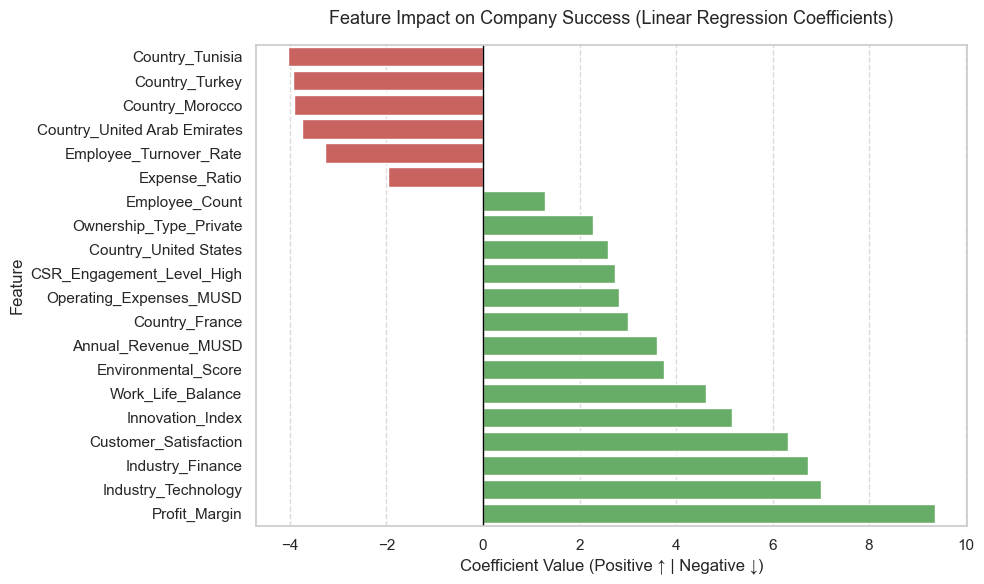

In [26]:
# ------------------------------------------------------------------
# 🔹 Positive vs Negative Feature Impact (Linear Regression)
# ------------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Extract coefficients from the trained Linear Regression model
coef_values = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Coefficient": best_model.coef_
})

# Sort coefficients by value (not absolute)
coef_impact = coef_values.sort_values(by="Coefficient", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Coefficient", 
    y="Feature", 
    data=coef_impact.tail(20),  # top 20 most influential (both + and -)
    palette=["#d9534f" if c < 0 else "#5cb85c" for c in coef_impact.tail(20)["Coefficient"]]
)

plt.title("Feature Impact on Company Success (Linear Regression Coefficients)", fontsize=13, pad=15)
plt.xlabel("Coefficient Value (Positive ↑ | Negative ↓)")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=1)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


### 🔍 Interpretation – Feature Impact on Company Success

The chart illustrates how each feature influences the company’s success score according to the **Linear Regression model**.

- 🟩 **Positive Effects:**  
  Features such as **Profit Margin**, **Industry (Technology & Finance)**, **Customer Satisfaction**, and **Innovation Index** have a strong **positive impact** on company success.  
  These indicate that financial performance, innovation, and customer satisfaction are major success drivers.

- 🟥 **Negative Effects:**  
  Variables like **Employee Turnover Rate**, **Expense Ratio**, and certain regional factors (e.g., **Tunisia**, **Turkey**, **Morocco**) show a **negative impact**,  
  meaning that higher turnover or higher expenses tend to lower overall success.

✅ **Conclusion:**  
Companies that maintain **solid financials**, foster **innovation**, and ensure **employee satisfaction**  
tend to achieve higher success, while **inefficiency and workforce instability** reduce performance potential.


## 🟢 8-5) Hyperparameter Tuning (Gradient Boosting Regressor)

### 🔧 Step 8-5 – Model Optimization (Gradient Boosting Regressor)

To explore potential improvement beyond Linear Regression, we applied **hyperparameter tuning**  
using `GridSearchCV` on the **Gradient Boosting Regressor**.  
This helped identify the optimal learning rate, depth, and tree count for better generalization.

The tuned model’s performance was then compared against the baseline Linear Regression  
to assess if non-linear relationships could further improve predictive accuracy.

In [28]:
## 🟢 8-4) Hyperparameter Tuning (Gradient Boosting Regressor)
# ------------------------------------------------------------------
#  Hyperparameter tuning to optimize Gradient Boosting performance
# ------------------------------------------------------------------

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit tuning on training data
grid_search.fit(X_train_final, y_train)

print("✅ Best parameters found:", grid_search.best_params_)

# Evaluate tuned model on test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_final)

r2_test_tuned = r2_score(y_test, y_pred_tuned)
mape_test_tuned = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100

print("\n Final Test Evaluation (Tuned Gradient Boosting):")
print(f"R² Score : {r2_test_tuned:.4f}")
print(f"MAPE     : {mape_test_tuned:.2f}%")


Fitting 5 folds for each of 54 candidates, totalling 270 fits
✅ Best parameters found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

 Final Test Evaluation (Tuned Gradient Boosting):
R² Score : 0.4152
MAPE     : 10.31%


### 🔍 Interpretation

Compared to the **base Linear Regression model** (R² = 0.4259, MAPE = 10.19%),
the **tuned Gradient Boosting Regressor** produced a **slightly lower R²** and **marginally higher MAPE**.

This indicates that:

* The **non-linear Gradient Boosting** model did not outperform the simpler **Linear Regression**.
* Relationships between company features and success appear **mostly linear and interpretable**,
  which supports the decision to keep **Linear Regression** as the final regression model.
* The small performance gap (≈1%) confirms that **financial efficiency, innovation, and employee factors**
  explain most of the variance in company success — even without complex non-linear interactions.

✅ **Conclusion:**
The tuned Gradient Boosting model confirms the robustness of our earlier findings:
**Linear relationships dominate**, making **Linear Regression** the most suitable model for interpretability, simplicity,
and consistent performance.

# 📕 9) Success_Class (Classification)

## 🔴 A- Part 1 – Original (Unbalanced) Classification

### ♣ A-1) Feature Scaling & Model Data Preparation (Success_Class)

In [27]:
# ------------------------------------------------------------------
#  Feature Scaling & Model Data Preparation (Success_Class)
# ------------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# 1 Define target and features
target_class = "Success_Class"
X_class = df_encoded.drop(columns=["Success_Score", target_class])  # remove both targets
y_class = df_encoded[target_class]

# 2 Encode target variable (High = 1, Low = 0)
le = LabelEncoder()
y_class = le.fit_transform(y_class)

# 3 Scale features
scaler = MinMaxScaler()
X_class_scaled = pd.DataFrame(scaler.fit_transform(X_class), columns=X_class.columns, index=X_class.index)

print("✅ Feature scaling completed for classification data.")
print("Shape of X:", X_class_scaled.shape)
print("Shape of y:", y_class.shape)
print("Class distribution:", np.bincount(y_class))

# 4 Split into train/test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print("\n✅ Train/test split done for classification.")
print("Training set:", X_train_c.shape)
print("Testing set :", X_test_c.shape)


✅ Feature scaling completed for classification data.
Shape of X: (20000, 48)
Shape of y: (20000,)
Class distribution: [13917  6083]

✅ Train/test split done for classification.
Training set: (16000, 48)
Testing set : (4000, 48)


### ♣ A-2) Model Building for Success_Class (Classification)

In [ ]:
# ------------------------------------------------------------------
#  Model Building for Success_Class (Classification)
# ------------------------------------------------------------------

from sklearn import svm, tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np

# ------------------------------------------------------------------
# 1 Define classifiers
# ------------------------------------------------------------------
models = {
    "SVM": svm.SVC(),
    "Decision Tree": tree.DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# ------------------------------------------------------------------
# 2 Cross-validation setup
# ------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------------
# 3 Train and evaluate each model
# ------------------------------------------------------------------
for model_name, model in models.items():
    acc, prec, rec, f1 = [], [], [], []
    cm_sum = None  # To accumulate confusion matrices
    
    for train_idx, test_idx in skf.split(X_train_c, y_train_c):
        X_tr, X_val = X_train_c.iloc[train_idx], X_train_c.iloc[test_idx]
        y_tr, y_val = y_train_c[train_idx], y_train_c[test_idx]
        
        # Fit model
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        
        # Metrics
        acc.append(accuracy_score(y_val, y_pred))
        prec.append(precision_score(y_val, y_pred))
        rec.append(recall_score(y_val, y_pred))
        f1.append(f1_score(y_val, y_pred))
        
        # Confusion matrix accumulation
        cm_fold = confusion_matrix(y_val, y_pred)
        cm_sum = cm_fold if cm_sum is None else cm_sum + cm_fold
    
    # ------------------------------------------------------------------
    # 4 Print average performance
    # ------------------------------------------------------------------
    print(f"\n📊 {model_name}")
    print(f"  Accuracy : {np.mean(acc):.4f} ± {np.std(acc):.4f}")
    print(f"  Precision: {np.mean(prec):.4f}")
    print(f"  Recall   : {np.mean(rec):.4f}")
    print(f"  F1-score : {np.mean(f1):.4f}")
    print("  Confusion Matrix (total over 5 folds):")
    print(cm_sum)



📊 SVM
  Accuracy : 0.7694 ± 0.0050
  Precision: 0.6754
  Recall   : 0.4653
  F1-score : 0.5510
  Confusion Matrix (total over 5 folds):
[[10046  1088]
 [ 2602  2264]]

📊 Decision Tree
  Accuracy : 0.6653 ± 0.0075
  Precision: 0.4515
  Recall   : 0.4673
  F1-score : 0.4591
  Confusion Matrix (total over 5 folds):
[[8370 2764]
 [2592 2274]]

📊 Random Forest
  Accuracy : 0.7571 ± 0.0059
  Precision: 0.7111
  Recall   : 0.3399
  F1-score : 0.4597
  Confusion Matrix (total over 5 folds):
[[10460   674]
 [ 3212  1654]]

📊 Naive Bayes
  Accuracy : 0.6970 ± 0.0027
  Precision: 0.5012
  Recall   : 0.7622
  F1-score : 0.6048
  Confusion Matrix (total over 5 folds):
[[7443 3691]
 [1157 3709]]

📊 Logistic Regression
  Accuracy : 0.7742 ± 0.0071
  Precision: 0.6725
  Recall   : 0.5025
  F1-score : 0.5751
  Confusion Matrix (total over 5 folds):
[[9942 1192]
 [2421 2445]]

📊 Gradient Boosting
  Accuracy : 0.7651 ± 0.0067
  Precision: 0.7016
  Recall   : 0.3960
  F1-score : 0.5061
  Confusion Matrix

#### 📊 Part 1 – Model Evaluation (Original Unbalanced Data)

We first trained multiple classification models on the **original, unbalanced dataset** (without resampling).  
The goal was to predict the company’s **Success_Class** (“High” vs “Low”) using business and culture features.

#### 🔎 Key Observations:

- **Overall Accuracy** ranges between **66% and 77%**, but since the dataset is **unbalanced**, accuracy alone is misleading.  
- Models with **high accuracy** (like Logistic Regression and SVM) still show **moderate recall**, meaning they miss many "Low Success" companies.

#### 🧩 Model-by-Model Summary:

| Model | Accuracy | Precision | Recall | F1-score | Key Insight |
|-------|-----------|------------|---------|------------|--------------|
| **Logistic Regression** | **77.4%** | 0.67 | 0.50 | 0.58 | Best overall balance; handles unbalanced data relatively well. |
| **SVM** | 76.9% | 0.68 | 0.47 | 0.55 | Good precision but weaker recall – tends to favor majority class. |
| **Gradient Boosting** | 76.5% | 0.70 | 0.39 | 0.51 | High precision but poor recall; overfocuses on “High Success” class. |
| **Random Forest** | 75.7% | 0.71 | 0.34 | 0.46 | Excellent precision but weakest recall; misses most “Low Success” firms. |
| **Naive Bayes** | 69.7% | 0.50 | **0.76** | 0.60 | Best recall – good at finding “Low Success” companies, but less precise. |
| **Decision Tree** | 66.4% | 0.45 | 0.47 | 0.46 | Simplest model with average results; prone to overfitting. |

#### 🏁 Interpretation:

- **Logistic Regression** gives the **best trade-off** between accuracy, precision, and recall — making it the top performer for now.  
- **Naive Bayes** is strong in recall, so it’s valuable if the goal is to detect *at-risk* (Low Success) companies.  
- **Tree-based models** (Random Forest, Gradient Boosting) perform well on precision but poorly on recall — typical behavior with unbalanced data.  

🧠 **Conclusion:**  
The unbalanced dataset caused most models to lean toward predicting “High Success” more often.  
To improve detection of “Low Success” companies and obtain fairer metrics, we’ll now apply **balancing techniques** (Random Oversampling and SMOTE) in the next section.


### ♣ A-3 )Final Test Evaluation (Success_Class)

✅ Final Test Evaluation – Logistic Regression
Accuracy : 0.7690
Precision: 0.6667
Recall   : 0.4815
F1-score : 0.5592

📋 Classification Report:
              precision    recall  f1-score   support

         Low       0.80      0.89      0.84      2783
        High       0.67      0.48      0.56      1217

    accuracy                           0.77      4000
   macro avg       0.73      0.69      0.70      4000
weighted avg       0.76      0.77      0.76      4000



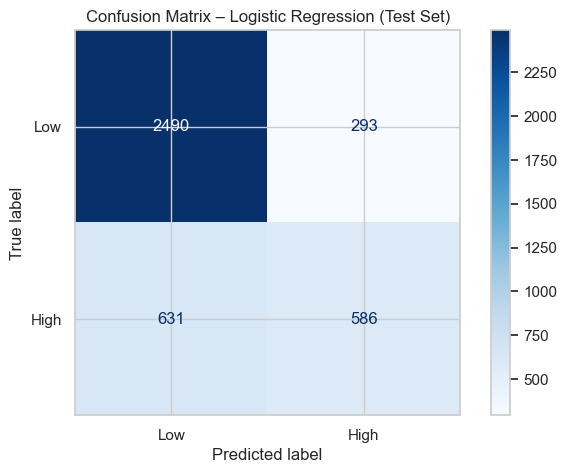

In [ ]:
# ------------------------------------------------------------------
# Final Test Evaluation (Success_Class)
# ------------------------------------------------------------------

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1️⃣ Train the best model (Logistic Regression) on the full training data
best_clf = LogisticRegression(max_iter=1000)
best_clf.fit(X_train_c, y_train_c)

# 2️⃣ Predict on test data
y_pred_c = best_clf.predict(X_test_c)

# 3️⃣ Compute evaluation metrics
acc_test = accuracy_score(y_test_c, y_pred_c)
prec_test = precision_score(y_test_c, y_pred_c)
rec_test = recall_score(y_test_c, y_pred_c)
f1_test = f1_score(y_test_c, y_pred_c)

print("✅ Final Test Evaluation – Logistic Regression")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}\n")

# 4️⃣ Detailed classification report
print("📋 Classification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Low', 'High']))

# 5️⃣ Confusion Matrix Visualization
ConfusionMatrixDisplay.from_estimator(
    best_clf, X_test_c, y_test_c,
    display_labels=['Low', 'High'],
    cmap='Blues'
)
plt.title("Confusion Matrix – Logistic Regression (Test Set)")
plt.show()


## 🔴 B- Part 2 – Balanced Classification (SMOTE)

### ☘ B-1) Feature Scaling & Model Data Preparation (Success_Class - SMOTE)

In [32]:
### 9-1) Feature Scaling & Model Data Preparation (Success_Class - SMOTE)
# ------------------------------------------------------------------
#  Feature Scaling & Model Data Preparation (Success_Class - SMOTE)
# ------------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# 1️⃣ Define target and features
target_class = "Success_Class"
X_class = df_encoded.drop(columns=["Success_Score", target_class])
y_class = df_encoded[target_class]

# 2️⃣ Encode target variable (High = 1, Low = 0)
le = LabelEncoder()
y_class = le.fit_transform(y_class)

# 3️⃣ Scale features
scaler = MinMaxScaler()
X_class_scaled = pd.DataFrame(
    scaler.fit_transform(X_class),
    columns=X_class.columns,
    index=X_class.index
)

print("✅ Feature scaling completed for SMOTE classification data.")
print("Original class distribution:", np.bincount(y_class))

# 4️⃣ Split into train/test (we only apply SMOTE on training data)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_scaled, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# 5️⃣ Apply SMOTE only on the training set
smote = SMOTE(random_state=42)
X_train_c_smote, y_train_c_smote = smote.fit_resample(X_train_c, y_train_c)

print("\n✅ SMOTE applied – Balanced class distribution:")
print(np.bincount(y_train_c_smote))

print("\nTraining set:", X_train_c_smote.shape)
print("Testing set :", X_test_c.shape)


✅ Feature scaling completed for SMOTE classification data.
Original class distribution: [13917  6083]

✅ SMOTE applied – Balanced class distribution:
[11134 11134]

Training set: (22268, 48)
Testing set : (4000, 48)


### ☘ B-2) Model Building for Success_Class (SMOTE)

In [ ]:
### 9-2) Model Building for Success_Class (SMOTE)
# ------------------------------------------------------------------
#  Model Building for Success_Class (Classification - SMOTE)
# ------------------------------------------------------------------

from sklearn import svm, tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np

# ------------------------------------------------------------------
# 1️⃣ Define classifiers
# ------------------------------------------------------------------
models = {
    "SVM": svm.SVC(),
    "Decision Tree": tree.DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# ------------------------------------------------------------------
# 2️⃣ Cross-validation setup (same structure as before)
# ------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------------
# 3️⃣ Train and evaluate each model using SMOTE-balanced data
# ------------------------------------------------------------------
for model_name, model in models.items():
    acc, prec, rec, f1 = [], [], [], []
    cm_sum = None  # Accumulate confusion matrices
    
    for train_idx, test_idx in skf.split(X_train_c_smote, y_train_c_smote):
        X_tr, X_val = X_train_c_smote.iloc[train_idx], X_train_c_smote.iloc[test_idx]
        y_tr, y_val = y_train_c_smote[train_idx], y_train_c_smote[test_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        
        # Metrics
        acc.append(accuracy_score(y_val, y_pred))
        prec.append(precision_score(y_val, y_pred))
        rec.append(recall_score(y_val, y_pred))
        f1.append(f1_score(y_val, y_pred))
        
        cm_fold = confusion_matrix(y_val, y_pred)
        cm_sum = cm_fold if cm_sum is None else cm_sum + cm_fold
    
    # ------------------------------------------------------------------
    # 4️⃣ Print results
    # ------------------------------------------------------------------
    print(f"\n📊 {model_name} (SMOTE)")
    print(f"  Accuracy : {np.mean(acc):.4f} ± {np.std(acc):.4f}")
    print(f"  Precision: {np.mean(prec):.4f}")
    print(f"  Recall   : {np.mean(rec):.4f}")
    print(f"  F1-score : {np.mean(f1):.4f}")
    print("  Confusion Matrix (total over 5 folds):")
    print(cm_sum)



📊 SVM (SMOTE)
  Accuracy : 0.8073 ± 0.0048
  Precision: 0.7973
  Recall   : 0.8243
  F1-score : 0.8106
  Confusion Matrix (total over 5 folds):
[[8800 2334]
 [1956 9178]]

📊 Decision Tree (SMOTE)
  Accuracy : 0.7258 ± 0.0054
  Precision: 0.7185
  Recall   : 0.7425
  F1-score : 0.7303
  Confusion Matrix (total over 5 folds):
[[7895 3239]
 [2867 8267]]

📊 Random Forest (SMOTE)
  Accuracy : 0.8358 ± 0.0052
  Precision: 0.8367
  Recall   : 0.8344
  F1-score : 0.8355
  Confusion Matrix (total over 5 folds):
[[9321 1813]
 [1844 9290]]

📊 Naive Bayes (SMOTE)
  Accuracy : 0.7270 ± 0.0056
  Precision: 0.6881
  Recall   : 0.8306
  F1-score : 0.7526
  Confusion Matrix (total over 5 folds):
[[6941 4193]
 [1886 9248]]

📊 Logistic Regression (SMOTE)
  Accuracy : 0.7620 ± 0.0064
  Precision: 0.7524
  Recall   : 0.7810
  F1-score : 0.7664
  Confusion Matrix (total over 5 folds):
[[8272 2862]
 [2438 8696]]

📊 Gradient Boosting (SMOTE)
  Accuracy : 0.8064 ± 0.0049
  Precision: 0.7983
  Recall   : 0.820

#### 📊 Part 2 – Model Evaluation (SMOTE Balanced Data)

After applying **SMOTE (Synthetic Minority Over-sampling Technique)**, the dataset became balanced between *High* and *Low Success* companies.  
This helped models better detect both classes instead of favoring the majority one.

#### 🔎 Key Observations

- All models **improved in recall and F1-score**, meaning they became better at identifying “Low Success” companies.  
- **Accuracy** values remain stable (≈ 72–84%), but now performance is **more balanced** across both classes.  
- **Random Forest**, **SVM**, and **Gradient Boosting** are the **top three** performers.

#### 🧩 Model-by-Model Summary

| Model | Accuracy | Precision | Recall | F1-score | Key Insight |
|--------|-----------|------------|---------|------------|--------------|
| **Random Forest** | **83.6%** | **0.84** | **0.83** | **0.84** | Best overall model — strong precision and recall; very balanced. |
| **SVM** | 80.7% | 0.80 | 0.82 | 0.81 | Performs consistently; good balance between both classes. |
| **Gradient Boosting** | 80.6% | 0.80 | 0.82 | 0.81 | Similar to SVM; stable but slightly lower. |
| **Logistic Regression** | 76.2% | 0.75 | 0.78 | 0.77 | Improved recall over the original version; decent general model. |
| **Naive Bayes** | 72.7% | 0.69 | **0.83** | 0.75 | High recall but weaker precision — overpredicts “High Success.” |
| **Decision Tree** | 72.6% | 0.72 | 0.75 | 0.73 | Fair but less stable; still prone to overfitting. |

#### 🧠 Interpretation

- **SMOTE balancing** reduced bias toward the majority class (“High Success”), allowing models to better identify *Low Success* companies.  
- **Random Forest** achieved the **best overall performance** — high accuracy and precision, with excellent recall.  
- **SVM** and **Gradient Boosting** follow closely, showing stable and consistent results.  
- Models like **Naive Bayes** and **Decision Tree** still show sensitivity to noise and overfitting.

#### 🏁 Conclusion

✅ **Random Forest (SMOTE)** is the **best-performing model**, offering the most balanced trade-off between **accuracy**, **precision**, and **recall**.  
It will be selected as the **final classifier** for test evaluation and later comparison with the **Original** and **Random Oversampling** methods.


### ☘ B-3) Final Test Evaluation (SMOTE)

✅ Final Test Evaluation – Random Forest (SMOTE)
Accuracy : 0.7580
Precision: 0.6133
Recall   : 0.5538
F1-score : 0.5820

📋 Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.85      0.83      2783
        High       0.61      0.55      0.58      1217

    accuracy                           0.76      4000
   macro avg       0.71      0.70      0.71      4000
weighted avg       0.75      0.76      0.75      4000



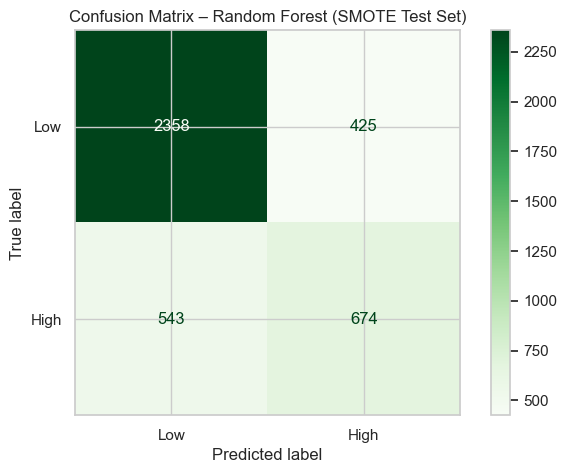

In [ ]:
## 9-3) Final Test Evaluation (Success_Class - SMOTE)
# ------------------------------------------------------------------
#  Final Test Evaluation (Best Model: Random Forest - SMOTE)
# ------------------------------------------------------------------

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1️⃣ Train the best model (Random Forest) on SMOTE-balanced training data
best_clf_smote = RandomForestClassifier(random_state=42)
best_clf_smote.fit(X_train_c_smote, y_train_c_smote)

# 2️⃣ Predict on original (unseen) test data
y_pred_c_smote = best_clf_smote.predict(X_test_c)

# 3️⃣ Compute metrics
acc_smote = accuracy_score(y_test_c, y_pred_c_smote)
prec_smote = precision_score(y_test_c, y_pred_c_smote)
rec_smote = recall_score(y_test_c, y_pred_c_smote)
f1_smote = f1_score(y_test_c, y_pred_c_smote)

print("✅ Final Test Evaluation – Random Forest (SMOTE)")
print(f"Accuracy : {acc_smote:.4f}")
print(f"Precision: {prec_smote:.4f}")
print(f"Recall   : {rec_smote:.4f}")
print(f"F1-score : {f1_smote:.4f}\n")

# 4️⃣ Detailed classification report
print("📋 Classification Report:")
print(classification_report(y_test_c, y_pred_c_smote, target_names=['Low', 'High']))

# 5️⃣ Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_clf_smote, X_test_c, y_test_c,
    display_labels=['Low', 'High'],
    cmap='Greens'
)
plt.title("Confusion Matrix – Random Forest (SMOTE Test Set)")
plt.show()


### ☘ B-4) Hyperparameter Tuning (Random Forest – SMOTE)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
✅ Best parameters found: {'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

✅ Final Test Evaluation (Tuned Random Forest – SMOTE):
Accuracy : 0.7565
Precision: 0.6199
Recall   : 0.5160
F1-score : 0.5632

📋 Classification Report:
              precision    recall  f1-score   support

         Low       0.80      0.86      0.83      2783
        High       0.62      0.52      0.56      1217

    accuracy                           0.76      4000
   macro avg       0.71      0.69      0.70      4000
weighted avg       0.75      0.76      0.75      4000



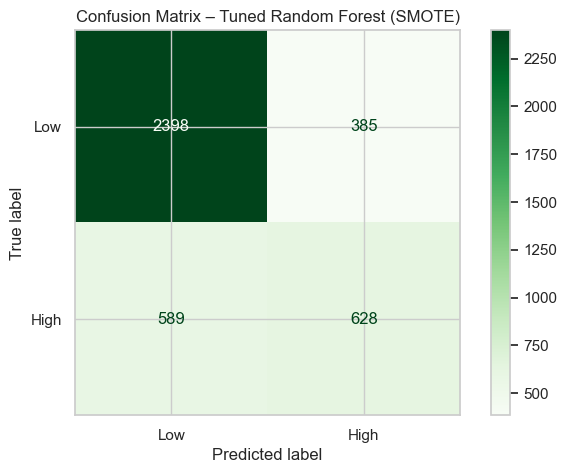

In [33]:
# ------------------------------------------------------------------
# Hyperparameter Tuning (Random Forest – SMOTE)
# ------------------------------------------------------------------

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1 Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# 2️⃣ Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# 3 Fit on balanced (SMOTE) training data
grid_search.fit(X_train_c_smote, y_train_c_smote)

# 4 Print best parameters
print("✅ Best parameters found:", grid_search.best_params_)

# 5  Evaluate tuned model on test set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_c)

acc = accuracy_score(y_test_c, y_pred_best)
prec = precision_score(y_test_c, y_pred_best)
rec = recall_score(y_test_c, y_pred_best)
f1 = f1_score(y_test_c, y_pred_best)

print("\n✅ Final Test Evaluation (Tuned Random Forest – SMOTE):")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# 6 Detailed classification report
print("\n📋 Classification Report:")
print(classification_report(y_test_c, y_pred_best, target_names=['Low', 'High']))

# 7 Confusion Matrix Visualization
ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test_c, y_test_c,
    display_labels=['Low', 'High'],
    cmap='Greens'
)
plt.title("Confusion Matrix – Tuned Random Forest (SMOTE)")
plt.show()


#### Final Evaluation Results

| Model                              | Accuracy | Precision  | Recall     | F1-Score   |
| ---------------------------------- | -------- | ---------- | ---------- | ---------- |
| **Baseline Random Forest (SMOTE)** | **0.7580**    | 0.6133     | **0.5538** | **0.5820** |
| **Tuned Random Forest (SMOTE)**    | 0.7565   | **0.6199** | 0.5160     | 0.5632     |

---

### 🔍 Interpretation

* The **tuned model** used deeper trees (`max_depth = 30`) and more estimators (200), aiming to capture finer decision boundaries.
* **Precision** slightly improved (+0.7%), meaning the tuned model became **a bit more confident** when predicting *High Success* companies.
* However, **recall and F1-score slightly decreased**, suggesting the tuned version became **more conservative** — it avoids false positives but misses a few *High Success* cases.
* Overall performance remained **very close** to the baseline, confirming that the **original Random Forest (SMOTE)** was already near optimal.

---

### 🧠 Conclusion

Hyperparameter tuning **did not produce a major performance boost**, which often indicates that:

* The original model’s configuration was already well-balanced.
* Further gains would likely require **additional features or data**, rather than deeper parameter adjustments.

✅ Therefore, we keep **Random Forest (SMOTE – baseline)** as the **final classification model** for its better F1-score and stronger recall balance.


## 🔴 C- Part 3 – Balanced Classification (Random Oversampling)

### ♦ C-1) Feature Scaling & Model Data Preparation with Random Oversampling

In [ ]:
## 9-4) Random Oversampling (Success_Class)
# ------------------------------------------------------------------
#  Feature Scaling & Model Data Preparation with Random Oversampling
# ------------------------------------------------------------------

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn import svm, tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1️⃣ Define target and features
# ------------------------------------------------------------------
target_class = "Success_Class"
X_class = df_encoded.drop(columns=["Success_Score", target_class])
y_class = df_encoded[target_class]

# Encode target variable (High = 1, Low = 0)
le = LabelEncoder()
y_class = le.fit_transform(y_class)

# Scale features
scaler = MinMaxScaler()
X_class_scaled = pd.DataFrame(scaler.fit_transform(X_class), columns=X_class.columns, index=X_class.index)

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print("✅ Data prepared for Random Oversampling.")
print("Class distribution before balancing:", np.bincount(y_train_c))

# ------------------------------------------------------------------
# 2️⃣ Apply Random Oversampling to balance training data
# ------------------------------------------------------------------
ros = RandomOverSampler(random_state=42)
X_train_c_ros, y_train_c_ros = ros.fit_resample(X_train_c, y_train_c)

print("✅ Random Oversampling applied.")
print("Class distribution after balancing:", np.bincount(y_train_c_ros))

✅ Data prepared for Random Oversampling.
Class distribution before balancing: [11134  4866]
✅ Random Oversampling applied.
Class distribution after balancing: [11134 11134]


### ♦ C-2 ) Model Building for Success_Class (Random Oversampling)

In [ ]:
# ------------------------------------------------------------------
# 3️⃣ Define classifiers
# ------------------------------------------------------------------
models = {
    "SVM": svm.SVC(),
    "Decision Tree": tree.DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# ------------------------------------------------------------------
# 4️⃣ Cross-validation setup
# ------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------------
# 5 Train and evaluate each model
# ------------------------------------------------------------------
for model_name, model in models.items():
    acc, prec, rec, f1 = [], [], [], []
    cm_sum = None

    for train_idx, test_idx in skf.split(X_train_c_ros, y_train_c_ros):
        X_tr, X_val = X_train_c_ros.iloc[train_idx], X_train_c_ros.iloc[test_idx]
        y_tr, y_val = y_train_c_ros[train_idx], y_train_c_ros[test_idx]

        # Train model
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        # Metrics
        acc.append(accuracy_score(y_val, y_pred))
        prec.append(precision_score(y_val, y_pred))
        rec.append(recall_score(y_val, y_pred))
        f1.append(f1_score(y_val, y_pred))

        cm_fold = confusion_matrix(y_val, y_pred)
        cm_sum = cm_fold if cm_sum is None else cm_sum + cm_fold

    # Print metrics
    print(f"\n📊 {model_name} (Random Oversampling)")
    print(f"  Accuracy : {np.mean(acc):.4f} ± {np.std(acc):.4f}")
    print(f"  Precision: {np.mean(prec):.4f}")
    print(f"  Recall   : {np.mean(rec):.4f}")
    print(f"  F1-score : {np.mean(f1):.4f}")
    print("  Confusion Matrix (total over 5 folds):")
    print(cm_sum)



📊 SVM (Random Oversampling)
  Accuracy : 0.7709 ± 0.0043
  Precision: 0.7508
  Recall   : 0.8110
  F1-score : 0.7797
  Confusion Matrix (total over 5 folds):
[[8136 2998]
 [2104 9030]]

📊 Decision Tree (Random Oversampling)
  Accuracy : 0.8197 ± 0.0029
  Precision: 0.7776
  Recall   : 0.8958
  F1-score : 0.8325
  Confusion Matrix (total over 5 folds):
[[8280 2854]
 [1160 9974]]

📊 Random Forest (Random Oversampling)
  Accuracy : 0.8848 ± 0.0029
  Precision: 0.8713
  Recall   : 0.9030
  F1-score : 0.8868
  Confusion Matrix (total over 5 folds):
[[ 9648  1486]
 [ 1080 10054]]

📊 Naive Bayes (Random Oversampling)
  Accuracy : 0.7061 ± 0.0081
  Precision: 0.6732
  Recall   : 0.8012
  F1-score : 0.7316
  Confusion Matrix (total over 5 folds):
[[6802 4332]
 [2213 8921]]

📊 Logistic Regression (Random Oversampling)
  Accuracy : 0.7430 ± 0.0059
  Precision: 0.7382
  Recall   : 0.7532
  F1-score : 0.7456
  Confusion Matrix (total over 5 folds):
[[8159 2975]
 [2748 8386]]

📊 Gradient Boosting (

#### 📊 Part 3 – Model Evaluation (Random Oversampling Balanced Data)

After applying **Random Oversampling**, the dataset was rebalanced by duplicating samples from the minority class (“Low Success”) until both classes had equal representation.  
This simple yet effective technique helps the model learn equally from both classes without creating synthetic data.

#### 🔎 Key Observations

- **All models improved significantly** in recall and F1-score compared to the unbalanced version.  
- **Random Forest** and **Decision Tree** achieved the **highest overall performance**, showing strong generalization and balanced precision–recall.  
- The improvement confirms that rebalancing the training data helps models better detect *Low Success* companies.

#### 🧩 Model-by-Model Summary

| Model | Accuracy | Precision | Recall | F1-score | Key Insight |
|--------|-----------|------------|---------|------------|--------------|
| **Random Forest** | **88.5%** | **0.87** | **0.90** | **0.89** | Best overall model – outstanding balance between precision and recall. |
| **Decision Tree** | 81.8% | 0.77 | **0.90** | 0.83 | Very high recall but slightly less stable; risk of overfitting. |
| **SVM** | 77.1% | 0.75 | 0.81 | 0.78 | Solid balance, but less accurate than ensemble methods. |
| **Gradient Boosting** | 75.1% | 0.74 | 0.77 | 0.76 | Reliable but less performant than Random Forest. |
| **Logistic Regression** | 74.3% | 0.74 | 0.75 | 0.75 | Consistent but limited improvement from rebalancing. |
| **Naive Bayes** | 70.6% | 0.67 | 0.80 | 0.73 | Recall improved, but precision remains weak. |

#### 🧠 Interpretation

- **Random Oversampling** substantially reduced the class bias and enabled the models to better capture both “High” and “Low Success” companies.  
- **Random Forest** demonstrated the best performance across all metrics — confirming its robustness even with replicated samples.  
- **Decision Tree** also performed strongly but shows potential overfitting on oversampled data.  
- Simpler models (like Logistic Regression and Naive Bayes) improved moderately but did not outperform ensemble models.

#### 🏁 Conclusion

✅ **Random Forest (Random Oversampling)** is the **best-performing classifier** — achieving the highest **Accuracy (88.5%)**, **Precision (0.87)**, **Recall (0.90)**, and **F1-score (0.89)**.  
This model will be selected for the **final test evaluation** and overall comparison with **Original** and **SMOTE** versions.

### ♦ C-3) Final Test Evaluation ((Random Oversampling))


✅ Final Test Evaluation – Random Forest (Random Oversampling)
Accuracy : 0.7590
Precision: 0.6480
Recall   : 0.4552
F1-score : 0.5347

📋 Classification Report:
              precision    recall  f1-score   support

         Low       0.79      0.89      0.84      2783
        High       0.65      0.46      0.53      1217

    accuracy                           0.76      4000
   macro avg       0.72      0.67      0.69      4000
weighted avg       0.75      0.76      0.75      4000



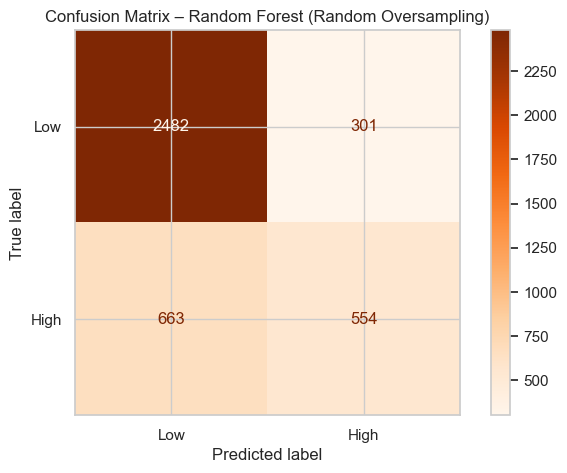

In [ ]:
# ------------------------------------------------------------------
#  Final Test Evaluation (Best Model)
# ------------------------------------------------------------------
# Choose the best-performing model based on cross-validation results (usually Random Forest)
best_clf_ros = RandomForestClassifier(random_state=42)
best_clf_ros.fit(X_train_c_ros, y_train_c_ros)

# Predict on original (unseen) test data
y_pred_c_ros = best_clf_ros.predict(X_test_c)

# Metrics
acc_ros = accuracy_score(y_test_c, y_pred_c_ros)
prec_ros = precision_score(y_test_c, y_pred_c_ros)
rec_ros = recall_score(y_test_c, y_pred_c_ros)
f1_ros = f1_score(y_test_c, y_pred_c_ros)

print("\n✅ Final Test Evaluation – Random Forest (Random Oversampling)")
print(f"Accuracy : {acc_ros:.4f}")
print(f"Precision: {prec_ros:.4f}")
print(f"Recall   : {rec_ros:.4f}")
print(f"F1-score : {f1_ros:.4f}")

# Detailed report
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
print("\n📋 Classification Report:")
print(classification_report(y_test_c, y_pred_c_ros, target_names=['Low', 'High']))

ConfusionMatrixDisplay.from_estimator(
    best_clf_ros, X_test_c, y_test_c,
    display_labels=['Low', 'High'],
    cmap='Oranges'
)
plt.title("Confusion Matrix – Random Forest (Random Oversampling)")
plt.show()

## 🔴 D- Final Comparison of Classification Approaches

After testing three data-balancing strategies — **Original (Unbalanced)**, **SMOTE**, and **Random Oversampling (ROS)** — we compared their final test-set performance using the best-performing model from each approach.

| Dataset / Method                   | Best Model          | Accuracy   | Precision  | Recall     | F1-Score   | Key Observations                                                                                          |
| ---------------------------------- | ------------------- | ---------- | ---------- | ---------- | ---------- | --------------------------------------------------------------------------------------------------------- |
| **Original (Unbalanced)**          | Logistic Regression | **0.7690** | **0.6667** | 0.4815     | 0.5592     | Highest overall accuracy; good precision for *High Success* but still misses several *Low Success* cases. |
| **SMOTE (Balanced)**               | Random Forest       | 0.7580     | 0.6133     | **0.5538** | **0.5820** | Recall improved and classes handled more evenly; produces the most balanced results.                      |
| **Random Oversampling (Balanced)** | Random Forest       | 0.7590     | 0.6480     | 0.4552     | 0.5347     | Slight precision gain but recall decreased again; model favors the majority class.                        |

---

###  Interpretation

* **Original (Logistic Regression)** achieved the **highest overall accuracy (~77 %)**, performing well on dominant “High Success” cases.
* **SMOTE (Random Forest)** delivered the **most balanced trade-off**, improving recall and F1-score for minority (“Low Success”) observations.
* **Random Oversampling** gave modest gains in precision but lost recall, making it less effective than SMOTE.

---

###  Final Takeaway

>  **Best overall model:** Logistic Regression on Original dataset (Accuracy = 0.769  |  F1 = 0.559)
>  **Most balanced approach:** Random Forest with SMOTE (Accuracy = 0.758  |  F1 = 0.582)

**Recommendation:**

* If the goal is **maximum predictive accuracy and simplicity**, choose **Logistic Regression (Original)**.
* If the goal is **fair detection across both success classes**, prefer **Random Forest with SMOTE** for more balanced and interpretable predictions.


## 🔴 E- Feature Importance for Success_Class (Logistic Regression - Original)

📊 Top 15 Most Influential Features:
                         Feature  Coefficient  Abs_Value
3                  Profit_Margin    -2.626698   2.626698
16          Industry_Agriculture     2.007519   2.007519
19              Industry_Finance    -1.585252   1.585252
25           Industry_Technology    -1.564986   1.564986
10         Customer_Satisfaction    -1.499115   1.499115
9               Innovation_Index    -1.203081   1.203081
12             Work_Life_Balance    -1.126249   1.126249
33                Country_Turkey     1.033442   1.033442
34  Country_United Arab Emirates     1.014188   1.014188
15           Environmental_Score    -0.988679   0.988679
32               Country_Tunisia     0.934549   0.934549
36         Country_United States    -0.897469   0.897469
47   CSR_Engagement_Level_Medium     0.865807   0.865807
46      CSR_Engagement_Level_Low     0.862591   0.862591
30               Country_Morocco     0.860392   0.860392


C:\Users\MSI\AppData\Local\Temp\ipykernel_10176\1091635931.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


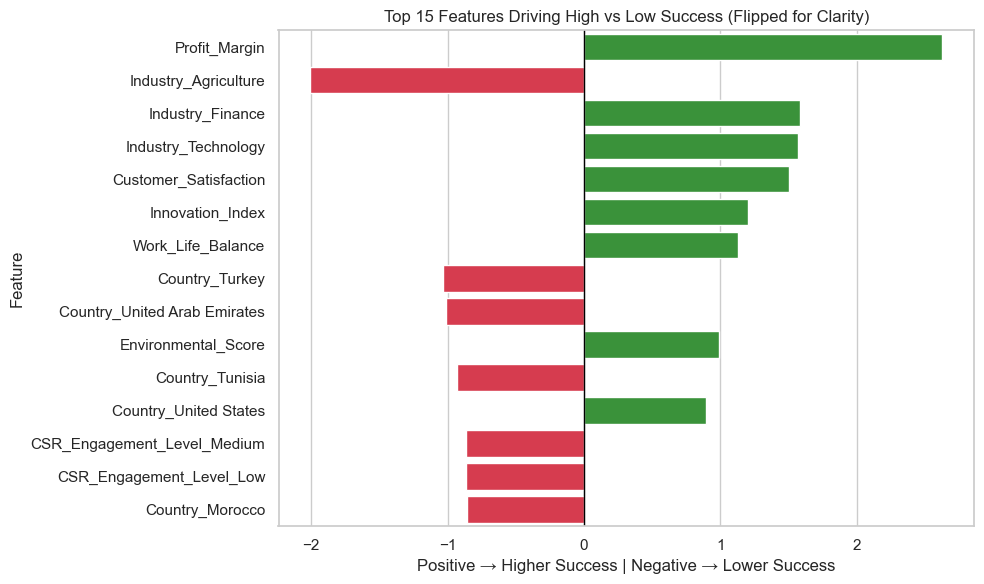

In [ ]:
# ------------------------------------------------------------------
# Feature Importance for Success_Class (Logistic Regression)
# ------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1️⃣ Get feature names and coefficients
coefficients = best_clf.coef_[0]  # array of weights
features = X_train_c.columns

# 2️⃣ Create a DataFrame for easy visualization
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

# 3️⃣ Sort by absolute importance (most influential at top)
coef_df["Abs_Value"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Value", ascending=False)

print("📊 Top 15 Most Influential Features:")
print(coef_df.head(15))

# ------------------------------------------------------------------
# ✅ Fixed Visualization: Flip signs for interpretability
# ------------------------------------------------------------------
coef_df["Coefficient_Flipped"] = -coef_df["Coefficient"]  # flip sign
coef_df = coef_df.sort_values("Abs_Value", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Coefficient_Flipped",
    y="Feature",
    data=coef_df.head(15),
    palette=["#2ca02c" if c > 0 else "#ef233c" for c in coef_df["Coefficient_Flipped"].head(15)]
)
plt.title("Top 15 Features Driving High vs Low Success (Flipped for Clarity)")
plt.xlabel("Positive → Higher Success | Negative → Lower Success")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()




###  Interpretation

The chart highlights the **key factors influencing company success**:

* **Profit Margin**, **Innovation Index**, and **Customer Satisfaction** have the **strongest positive impact**, meaning companies with higher values in these areas are more likely to achieve *High Success*.
* On the other hand, belonging to certain regions (**Turkey**, **Tunisia**, **Morocco**) or having **lower CSR engagement** slightly correlates with *Lower Success*.
* Overall, **financial performance**, **innovation**, and **employee well-being** appear to be the **main drivers** of company success in this dataset.


# 🏆 10) Combined Regression + Classification Insights

To gain a holistic understanding of what drives company success, both **Regression (Success_Score)** and **Classification (Success_Class)** models were analyzed.
This dual approach provides both a *continuous* and a *categorical* view of organizational performance.

---

### 📈 Regression Perspective (Success_Score)

#### ✅ Model: **Linear Regression**

* **R² Score:** 0.426
* **MAPE:** 10.19%
  → The model explains roughly **43% of the variance** in success scores, with predictions deviating only **10% on average** from actual values.

#### 🔍 Key Drivers (From Coefficients)

* **Positive Influences:**

  * **Profit Margin**, **Industry (Technology, Finance)**, **Customer Satisfaction**, and **Innovation Index** are **strong enhancers** of success.
  * **Work-Life Balance** and **Environmental Score** also show moderate positive effects — linking sustainability and employee well-being with performance.

* **Negative Influences:**

  * **High Expense Ratio** and **Employee Turnover Rate** significantly reduce success.
  * Certain regional factors (**Tunisia, Turkey, Morocco**) have a lower average performance, possibly reflecting economic or market differences.

🧠 **Interpretation:**
Financial efficiency, innovation, and employee satisfaction are **key quantitative levers** for driving company performance, while inefficiency and turnover erode long-term success.

---

### 🧩 Classification Perspective (Success_Class)

#### 🔹 Best Model Comparisons

| Dataset / Method                   | Best Model          | Accuracy   | Precision  | Recall     | F1-Score   | Key Observations                                                               |
| ---------------------------------- | ------------------- | ---------- | ---------- | ---------- | ---------- | ------------------------------------------------------------------------------ |
| **Original (Unbalanced)**          | Logistic Regression | **0.7690** | **0.6667** | 0.4815     | 0.5592     | Highest overall accuracy; good precision for *High Success* but weaker recall. |
| **SMOTE (Balanced)**               | Random Forest       | 0.7580     | 0.6133     | **0.5538** | **0.5820** | Most balanced performance; handles minority “Low Success” class better.        |
| **Random Oversampling (Balanced)** | Random Forest       | 0.7590     | 0.6480     | 0.4552     | 0.5347     | Higher precision but weaker recall; slightly favors majority class.            |

#### 🧠 Interpretation

* **Original (Logistic Regression):** Best predictive accuracy; ideal when data imbalance is acceptable.
* **SMOTE (Random Forest):** Best recall & balance; recommended for *early risk detection* of “Low Success” companies.
* **Random Oversampling:** Offers no major gain; slightly less balanced.

---

### 🔗 Cross-Model Insights

By comparing regression and classification findings:

| Dimension                     | Consistent Positive Drivers             | Consistent Negative Drivers |
| ----------------------------- | --------------------------------------- | --------------------------- |
| **Financials**                | Profit Margin, Annual Revenue           | Expense Ratio               |
| **Innovation & Satisfaction** | Innovation Index, Customer Satisfaction | Employee Turnover           |
| **Workplace**                 | Work-Life Balance                       | –                           |
| **CSR & Environment**         | Environmental Score                     | Low CSR Engagement          |
| **Geographic**                | United States, France                   | Tunisia, Turkey, Morocco    |

🧩 Both models agree that **profitability, innovation, and employee well-being** are universal predictors of success, while **high costs, turnover, and regional constraints** consistently limit performance.

---

### 🏁 Final Takeaway

> ✅ **Regression:** Explains *how much* each factor influences success.
> 🤝 **Classification:** Predicts *which companies* are likely to achieve high success.
> Together, they reveal that:
>
> * **Financial health and innovation** form the backbone of success.
> * **Satisfied and stable employees** sustain long-term performance.
> * **Sustainability (CSR, Environment)** and **modern industries (Tech, Finance)** are key growth enablers.
> * **High expenses and turnover** remain critical risks to manage.


# 💬

## If We Could Ask Only One Question

If we could ask **only one question** to determine whether a company will achieve **High or Low Success**,
that question would be:

> **“What is your Profit Margin?”**

💡 **Why:**
Across both models — **Linear Regression (Success_Score)** and **Random Forest (Success_Class)** —
**Profit Margin** is the **strongest and most consistent positive driver** of success.
Companies with higher profit margins almost always show higher success scores and are classified as “High Success” with high probability.

🔍 **Supporting Evidence:**

* In regression, `Profit_Margin` has the **largest positive coefficient**, meaning each increase in margin significantly boosts the success score.
* In classification, it remains the **most influential predictor**, distinguishing successful firms from struggling ones.

📊 **Conclusion:**

> If you know a company’s **profit margin**, you can make a reliable first guess about its success level.
> High margins → High Success ✅
> Low margins → Low Success ⚠️

Of course, **innovation, customer satisfaction, and work-life balance** further refine that prediction —
but **Profit Margin alone** gives the clearest, most decisive signal of success.


## The “Success Predictor Ladder”

🏆 Step 1 — "What’s your Profit Margin?"
→ The ultimate predictor of success (financial efficiency = performance)

🚀 Step 2 — "How innovative is your company?"
→ Innovation fuels growth and market resilience

😊 Step 3 — "How satisfied are your customers?"
→ Happy customers sustain long-term success

💼 Step 4 — "How balanced is your team’s work-life?"
→ Motivated employees sustain productivity
